In [1]:
"""
Experiment 04: Channel Clustering on a Full Na/K Excitable Membrane Model

Goal:
Build a more realistic excitable-cell model using competing sodium, potassium,
and leak currents before testing whether sodium channel clustering changes
action potential reliability.

Why this notebook exists:
The earlier simplified clustering model entered a persistent depolarized state
and could not meaningfully distinguish spike success across cluster fractions.
This notebook rebuilds the experiment on a more complete Hodgkin-Huxley-style
framework.

Main objectives:
1. Confirm that the model produces a realistic spike-like voltage trace
2. Understand the roles of Na, K, and leak currents
3. Prepare this model for later clustering experiments
"""

'\nExperiment 04: Channel Clustering on a Full Na/K Excitable Membrane Model\n\nGoal:\nBuild a more realistic excitable-cell model using competing sodium, potassium,\nand leak currents before testing whether sodium channel clustering changes\naction potential reliability.\n\nWhy this notebook exists:\nThe earlier simplified clustering model entered a persistent depolarized state\nand could not meaningfully distinguish spike success across cluster fractions.\nThis notebook rebuilds the experiment on a more complete Hodgkin-Huxley-style\nframework.\n\nMain objectives:\n1. Confirm that the model produces a realistic spike-like voltage trace\n2. Understand the roles of Na, K, and leak currents\n3. Prepare this model for later clustering experiments\n'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
# Time settings
dt = 0.01
T = 50
steps = int(T / dt)
time = np.linspace(0, T, steps)

# Membrane parameters
C_m = 1.0
g_Na = 120.0
g_K = 36.0
g_L = 0.3

E_Na = 50.0
E_K = -77.0
E_L = -54.4

# Starting voltage
V = -65.0

# Initial gating variables
m = 0.05
h = 0.60
n = 0.32

In [6]:
# Storage for results
V_history = []
m_history = []
h_history = []
n_history = []
I_Na_history = []
I_K_history = []
I_L_history = []

In [7]:
for i in range(steps):
    
    # --- Gating variable rate constants ---
    alpha_m = 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10))
    beta_m = 4.0 * np.exp(-(V + 65) / 18)

    alpha_h = 0.07 * np.exp(-(V + 65) / 20)
    beta_h = 1 / (1 + np.exp(-(V + 35) / 10))

    alpha_n = 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10))
    beta_n = 0.125 * np.exp(-(V + 65) / 80)

    # --- Update gating variables ---
    m += (alpha_m * (1 - m) - beta_m * m) * dt
    h += (alpha_h * (1 - h) - beta_h * h) * dt
    n += (alpha_n * (1 - n) - beta_n * n) * dt

    # --- Currents ---
    I_Na = g_Na * (m**3) * h * (V - E_Na)
    I_K = g_K * (n**4) * (V - E_K)
    I_L = g_L * (V - E_L)

    # --- External stimulus ---
    I_ext = 10 if 5 <= time[i] < 15 else 0

    # --- Voltage update ---
    V += (-(I_Na + I_K + I_L) + I_ext) / C_m * dt

    # --- Store values ---
    V_history.append(V)
    m_history.append(m)
    h_history.append(h)
    n_history.append(n)
    I_Na_history.append(I_Na)
    I_K_history.append(I_K)
    I_L_history.append(I_L)

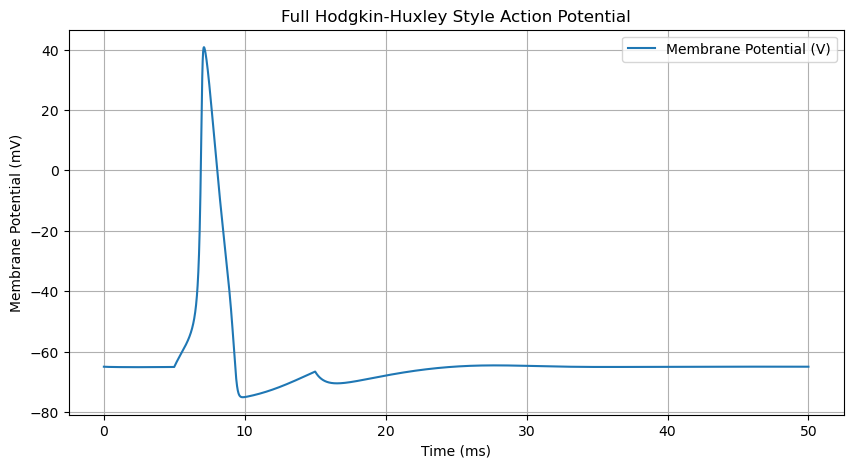

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(time, V_history, label="Membrane Potential (V)")
plt.title("Full Hodgkin-Huxley Style Action Potential")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.grid(True)
plt.legend()
plt.savefig("full_HH_action_potential.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# Channel distribution parameters
cluster_fraction = 0.5

g_Na_cluster = g_Na * cluster_fraction
g_Na_diffuse = g_Na * (1 - cluster_fraction)

In [10]:
print("Clustered sodium conductance:", g_Na_cluster)
print("Diffuse sodium conductance:", g_Na_diffuse)
print("Total sodium conductance:", g_Na_cluster + g_Na_diffuse)

Clustered sodium conductance: 60.0
Diffuse sodium conductance: 60.0
Total sodium conductance: 120.0


In [11]:
for i in range(steps):
    
    # --- Gating variable rate constants ---
    alpha_m = 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10))
    beta_m = 4.0 * np.exp(-(V + 65) / 18)

    alpha_h = 0.07 * np.exp(-(V + 65) / 20)
    beta_h = 1 / (1 + np.exp(-(V + 35) / 10))

    alpha_n = 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10))
    beta_n = 0.125 * np.exp(-(V + 65) / 80)

    # --- Update gating variables ---
    m += (alpha_m * (1 - m) - beta_m * m) * dt
    h += (alpha_h * (1 - h) - beta_h * h) * dt
    n += (alpha_n * (1 - n) - beta_n * n) * dt

    # --- Sodium currents (cluster + diffuse) ---
    I_Na_cluster = g_Na_cluster * (m**3) * h * (V - E_Na)
    I_Na_diffuse = g_Na_diffuse * (m**3) * h * (V - E_Na)

    I_Na_total = I_Na_cluster + I_Na_diffuse

    # --- Other currents ---
    I_K = g_K * (n**4) * (V - E_K)
    I_L = g_L * (V - E_L)

    # --- External stimulus ---
    I_ext = 10 if 5 <= time[i] < 6 else 0

    # --- Voltage update ---
    V += (-(I_Na_total + I_K + I_L) + I_ext) / C_m * dt

    # --- Store values ---
    V_history.append(V)
    m_history.append(m)
    h_history.append(h)
    n_history.append(n)
    I_Na_history.append(I_Na_total)
    I_K_history.append(I_K)
    I_L_history.append(I_L)

In [12]:
# Two-compartment starting conditions
V_cluster = -65.0
V_diffuse = -65.0

# Shared initial gating variables
m_cluster, h_cluster, n_cluster = 0.05, 0.60, 0.32
m_diffuse, h_diffuse, n_diffuse = 0.05, 0.60, 0.32

# Coupling conductance between compartments
g_c = 1.0

In [13]:
# Storage for two-compartment results
V_cluster_history = []
V_diffuse_history = []

In [14]:
# Reset time axis for the two-compartment simulation
time = np.linspace(0, T, steps)

In [15]:
for i in range(steps):

    # --- Rate constants (cluster compartment) ---
    alpha_m_c = 0.1 * (V_cluster + 40) / (1 - np.exp(-(V_cluster + 40) / 10))
    beta_m_c = 4.0 * np.exp(-(V_cluster + 65) / 18)

    alpha_h_c = 0.07 * np.exp(-(V_cluster + 65) / 20)
    beta_h_c = 1 / (1 + np.exp(-(V_cluster + 35) / 10))

    alpha_n_c = 0.01 * (V_cluster + 55) / (1 - np.exp(-(V_cluster + 55) / 10))
    beta_n_c = 0.125 * np.exp(-(V_cluster + 65) / 80)

    # --- Rate constants (diffuse compartment) ---
    alpha_m_d = 0.1 * (V_diffuse + 40) / (1 - np.exp(-(V_diffuse + 40) / 10))
    beta_m_d = 4.0 * np.exp(-(V_diffuse + 65) / 18)

    alpha_h_d = 0.07 * np.exp(-(V_diffuse + 65) / 20)
    beta_h_d = 1 / (1 + np.exp(-(V_diffuse + 35) / 10))

    alpha_n_d = 0.01 * (V_diffuse + 55) / (1 - np.exp(-(V_diffuse + 55) / 10))
    beta_n_d = 0.125 * np.exp(-(V_diffuse + 65) / 80)

    # --- Update gating variables ---
    m_cluster += (alpha_m_c * (1 - m_cluster) - beta_m_c * m_cluster) * dt
    h_cluster += (alpha_h_c * (1 - h_cluster) - beta_h_c * h_cluster) * dt
    n_cluster += (alpha_n_c * (1 - n_cluster) - beta_n_c * n_cluster) * dt

    m_diffuse += (alpha_m_d * (1 - m_diffuse) - beta_m_d * m_diffuse) * dt
    h_diffuse += (alpha_h_d * (1 - h_diffuse) - beta_h_d * h_diffuse) * dt
    n_diffuse += (alpha_n_d * (1 - n_diffuse) - beta_n_d * n_diffuse) * dt

    # --- Currents (cluster compartment) ---
    I_Na_c = g_Na_cluster * (m_cluster**3) * h_cluster * (V_cluster - E_Na)
    I_K_c = g_K * (n_cluster**4) * (V_cluster - E_K)
    I_L_c = g_L * (V_cluster - E_L)

    # --- Currents (diffuse compartment) ---
    I_Na_d = g_Na_diffuse * (m_diffuse**3) * h_diffuse * (V_diffuse - E_Na)
    I_K_d = g_K * (n_diffuse**4) * (V_diffuse - E_K)
    I_L_d = g_L * (V_diffuse - E_L)

    # --- Coupling current ---
    I_couple = g_c * (V_diffuse - V_cluster)

    # --- External stimulus (applied to cluster region) ---
    I_ext = 10 if 5 <= time[i] < 6 else 0

    # --- Voltage updates ---
    V_cluster += (-(I_Na_c + I_K_c + I_L_c) + I_ext + I_couple) / C_m * dt
    V_diffuse += (-(I_Na_d + I_K_d + I_L_d) - I_couple) / C_m * dt

    # --- Store values ---
    V_cluster_history.append(V_cluster)
    V_diffuse_history.append(V_diffuse)

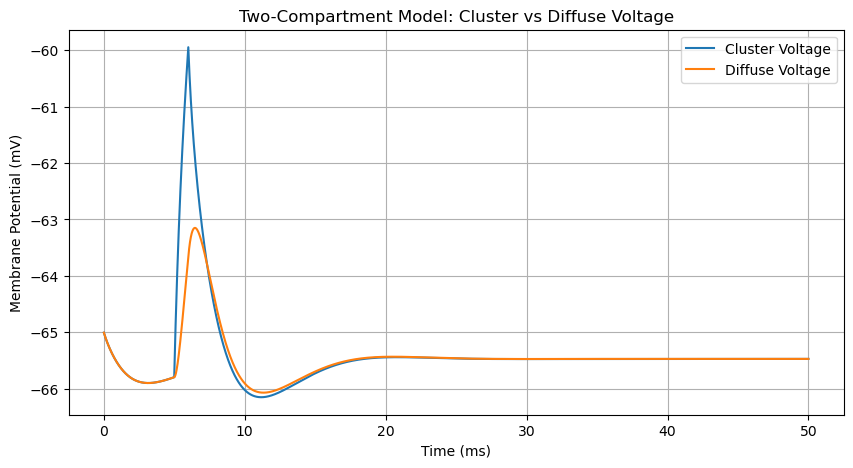

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(time, V_cluster_history, label="Cluster Voltage")
plt.plot(time, V_diffuse_history, label="Diffuse Voltage")
plt.title("Two-Compartment Model: Cluster vs Diffuse Voltage")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.legend()
plt.grid(True)
plt.savefig("two_compartment_voltage.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# Reset two-compartment histories
V_cluster_history = []
V_diffuse_history = []

In [18]:
# Function to test if spike occurs
def check_spike(V_trace):
    return any(v > 0 for v in V_trace)

In [19]:
def run_two_compartment_simulation(cluster_fraction, T=50, dt=0.01):
    steps = int(T / dt)
    time = np.linspace(0, T, steps)

    # Fixed total sodium conductance, redistributed by cluster_fraction
    g_Na_total = 120.0
    g_Na_cluster = g_Na_total * cluster_fraction
    g_Na_diffuse = g_Na_total * (1 - cluster_fraction)

    # Other membrane parameters
    C_m = 1.0
    g_K = 36.0
    g_L = 0.3
    g_c = 1.0

    E_Na = 50.0
    E_K = -77.0
    E_L = -54.4

    # Initial voltages
    V_cluster = -65.0
    V_diffuse = -65.0

    # Initial gating variables
    m_cluster, h_cluster, n_cluster = 0.05, 0.60, 0.32
    m_diffuse, h_diffuse, n_diffuse = 0.05, 0.60, 0.32

    # Storage
    V_cluster_history = []
    V_diffuse_history = []

    for i in range(steps):
        # Cluster rates
        alpha_m_c = 0.1 * (V_cluster + 40) / (1 - np.exp(-(V_cluster + 40) / 10))
        beta_m_c = 4.0 * np.exp(-(V_cluster + 65) / 18)

        alpha_h_c = 0.07 * np.exp(-(V_cluster + 65) / 20)
        beta_h_c = 1 / (1 + np.exp(-(V_cluster + 35) / 10))

        alpha_n_c = 0.01 * (V_cluster + 55) / (1 - np.exp(-(V_cluster + 55) / 10))
        beta_n_c = 0.125 * np.exp(-(V_cluster + 65) / 80)

        # Diffuse rates
        alpha_m_d = 0.1 * (V_diffuse + 40) / (1 - np.exp(-(V_diffuse + 40) / 10))
        beta_m_d = 4.0 * np.exp(-(V_diffuse + 65) / 18)

        alpha_h_d = 0.07 * np.exp(-(V_diffuse + 65) / 20)
        beta_h_d = 1 / (1 + np.exp(-(V_diffuse + 35) / 10))

        alpha_n_d = 0.01 * (V_diffuse + 55) / (1 - np.exp(-(V_diffuse + 55) / 10))
        beta_n_d = 0.125 * np.exp(-(V_diffuse + 65) / 80)

        # Update gating variables
        m_cluster += (alpha_m_c * (1 - m_cluster) - beta_m_c * m_cluster) * dt
        h_cluster += (alpha_h_c * (1 - h_cluster) - beta_h_c * h_cluster) * dt
        n_cluster += (alpha_n_c * (1 - n_cluster) - beta_n_c * n_cluster) * dt

        m_diffuse += (alpha_m_d * (1 - m_diffuse) - beta_m_d * m_diffuse) * dt
        h_diffuse += (alpha_h_d * (1 - h_diffuse) - beta_h_d * h_diffuse) * dt
        n_diffuse += (alpha_n_d * (1 - n_diffuse) - beta_n_d * n_diffuse) * dt

        # Currents
        I_Na_c = g_Na_cluster * (m_cluster**3) * h_cluster * (V_cluster - E_Na)
        I_K_c = g_K * (n_cluster**4) * (V_cluster - E_K)
        I_L_c = g_L * (V_cluster - E_L)

        I_Na_d = g_Na_diffuse * (m_diffuse**3) * h_diffuse * (V_diffuse - E_Na)
        I_K_d = g_K * (n_diffuse**4) * (V_diffuse - E_K)
        I_L_d = g_L * (V_diffuse - E_L)

        I_couple = g_c * (V_diffuse - V_cluster)

        # Stimulus to cluster compartment only
        I_ext = 20 if 5 <= time[i] < 7 else 0

        # Voltage updates
        V_cluster += (-(I_Na_c + I_K_c + I_L_c) + I_ext + I_couple) / C_m * dt
        V_diffuse += (-(I_Na_d + I_K_d + I_L_d) - I_couple) / C_m * dt

        # Store
        V_cluster_history.append(V_cluster)
        V_diffuse_history.append(V_diffuse)

    return time, V_cluster_history, V_diffuse_history

In [20]:
time, V_c, V_d = run_two_compartment_simulation(cluster_fraction=0.5)

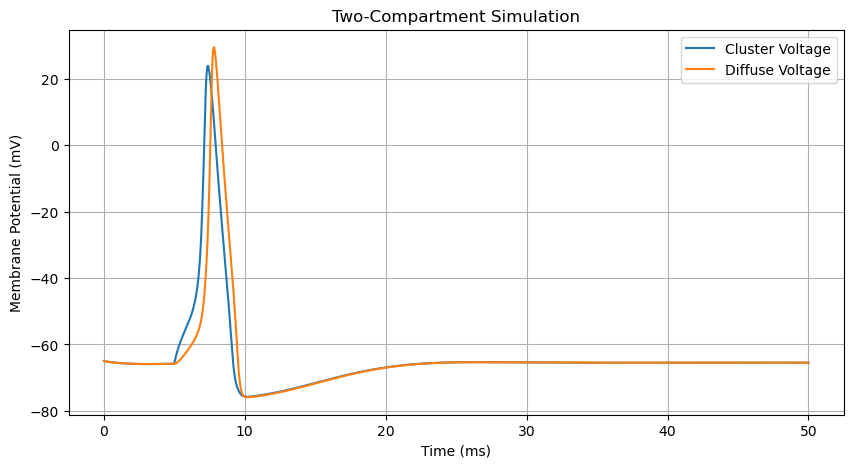

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(time, V_c, label="Cluster Voltage")
plt.plot(time, V_d, label="Diffuse Voltage")
plt.title("Two-Compartment Simulation")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
time, V_c, V_d = run_two_compartment_simulation(cluster_fraction=0.1)

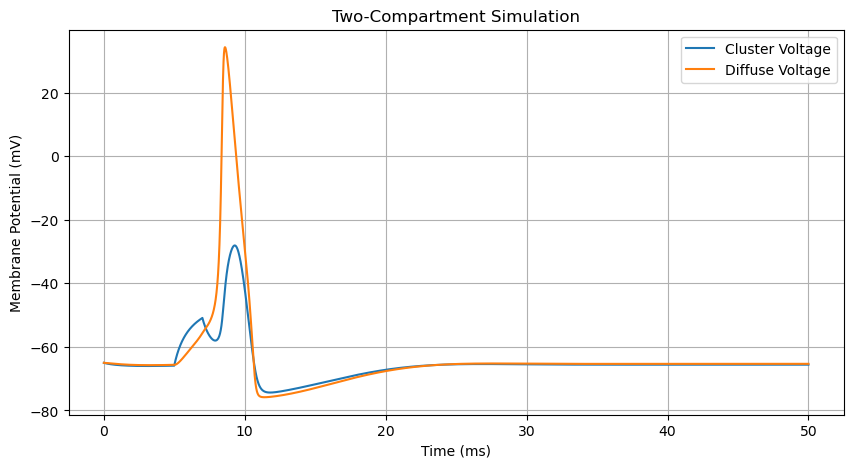

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(time, V_c, label="Cluster Voltage")
plt.plot(time, V_d, label="Diffuse Voltage")
plt.title("Two-Compartment Simulation")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.legend()
plt.grid(True)
plt.show()

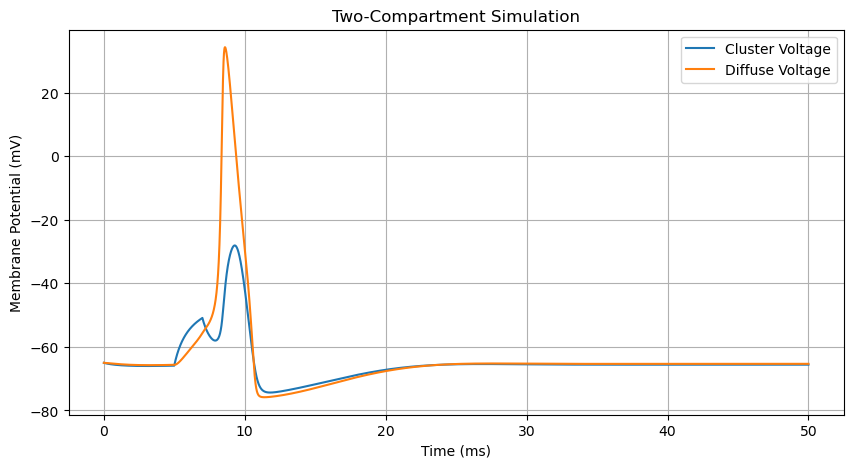

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(time, V_c, label="Cluster Voltage")
plt.plot(time, V_d, label="Diffuse Voltage")
plt.title("Two-Compartment Simulation")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
print("Cluster spike success:", check_spike(V_c))
print("Diffuse spike success:", check_spike(V_d))
print("Cluster max voltage:", max(V_c))
print("Diffuse max voltage:", max(V_d))

Cluster spike success: False
Diffuse spike success: True
Cluster max voltage: -28.10111416616567
Diffuse max voltage: 34.24278340750702


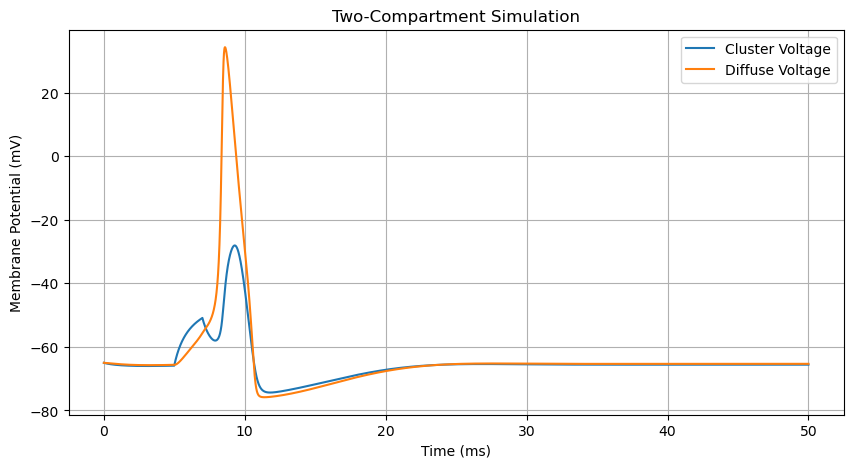

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(time, V_c, label="Cluster Voltage")
plt.plot(time, V_d, label="Diffuse Voltage")
plt.title("Two-Compartment Simulation")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
print("Cluster spike success:", check_spike(V_c))
print("Diffuse spike success:", check_spike(V_d))
print("Cluster max voltage:", max(V_c))
print("Diffuse max voltage:", max(V_d))

Cluster spike success: False
Diffuse spike success: True
Cluster max voltage: -28.10111416616567
Diffuse max voltage: 34.24278340750702


In [28]:
cluster_values = np.linspace(0, 1, 10)
cluster_success = []
diffuse_success = []

for f in cluster_values:
    time, V_c, V_d = run_two_compartment_simulation(cluster_fraction=f)
    
    cluster_success.append(check_spike(V_c))
    diffuse_success.append(check_spike(V_d))

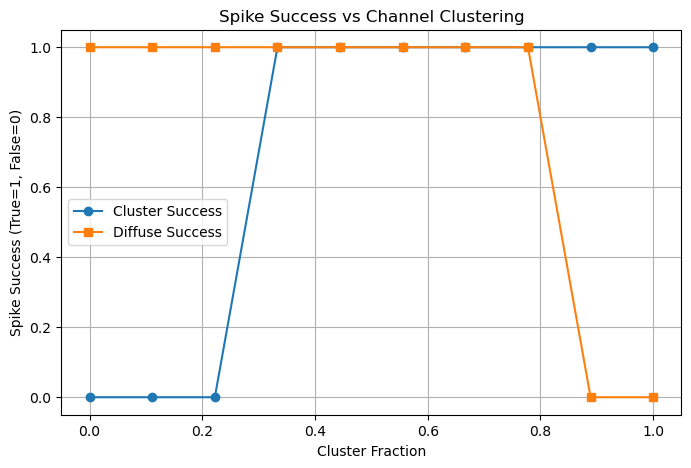

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_values, cluster_success, marker='o', label="Cluster Success")
plt.plot(cluster_values, diffuse_success, marker='s', label="Diffuse Success")
plt.xlabel("Cluster Fraction")
plt.ylabel("Spike Success (True=1, False=0)")
plt.title("Spike Success vs Channel Clustering")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
cluster_values = np.linspace(0.3, 0.8, 50)
cluster_success = []
diffuse_success = []

for f in cluster_values:
    time, V_c, V_d = run_two_compartment_simulation(cluster_fraction=f)
    cluster_success.append(int(check_spike(V_c)))
    diffuse_success.append(int(check_spike(V_d)))

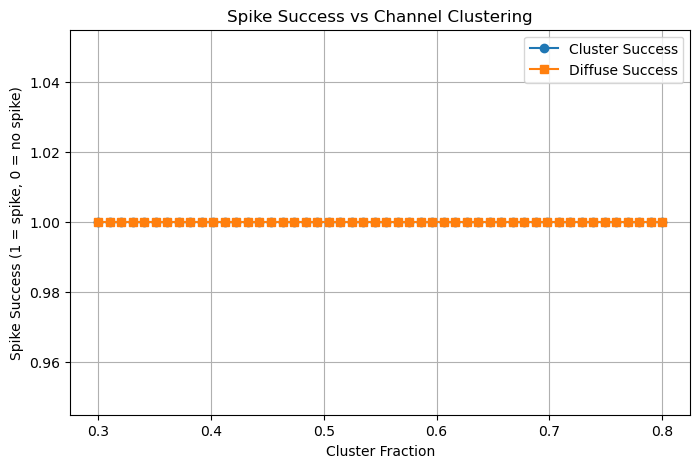

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_values, cluster_success, marker='o', label="Cluster Success")
plt.plot(cluster_values, diffuse_success, marker='s', label="Diffuse Success")
plt.xlabel("Cluster Fraction")
plt.ylabel("Spike Success (1 = spike, 0 = no spike)")
plt.title("Spike Success vs Channel Clustering")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
cluster_max = []
diffuse_max = []

for f in cluster_values:
    time, V_c, V_d = run_two_compartment_simulation(cluster_fraction=f)
    cluster_max.append(max(V_c))
    diffuse_max.append(max(V_d))

In [33]:
both_spike_indices = []
mismatch_values = []

for i in range(len(cluster_values)):
    if cluster_success[i] == 1 and diffuse_success[i] == 1:
        both_spike_indices.append(i)
        mismatch = abs(cluster_max[i] - diffuse_max[i])
        mismatch_values.append(mismatch)

if len(both_spike_indices) > 0:
    best_local_index = mismatch_values.index(min(mismatch_values))
    best_global_index = both_spike_indices[best_local_index]

    optimal_cluster_fraction = cluster_values[best_global_index]
    optimal_cluster_max = cluster_max[best_global_index]
    optimal_diffuse_max = diffuse_max[best_global_index]
    optimal_mismatch = mismatch_values[best_local_index]

    print("Optimal cluster_fraction:", optimal_cluster_fraction)
    print("Cluster max voltage at optimum:", optimal_cluster_max)
    print("Diffuse max voltage at optimum:", optimal_diffuse_max)
    print("Voltage mismatch at optimum:", optimal_mismatch)
else:
    print("No cluster_fraction values found where both compartments spike.")

Optimal cluster_fraction: 0.5653061224489795
Cluster max voltage at optimum: 27.419679624515517
Diffuse max voltage at optimum: 27.002126868395955
Voltage mismatch at optimum: 0.4175527561195622


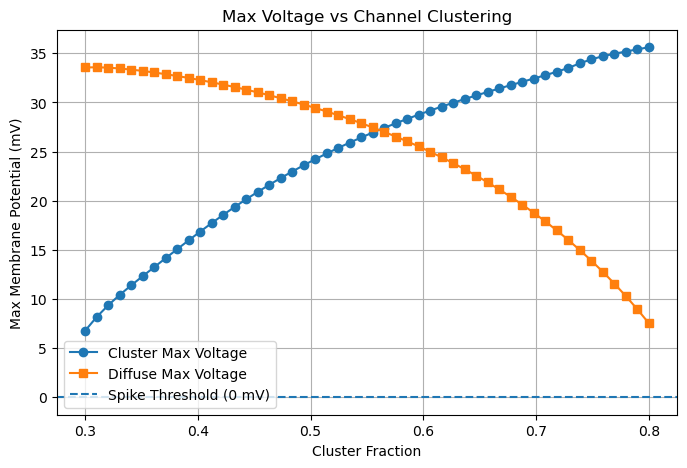

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_values, cluster_max, marker='o', label="Cluster Max Voltage")
plt.plot(cluster_values, diffuse_max, marker='s', label="Diffuse Max Voltage")
plt.axhline(0, linestyle='--', label="Spike Threshold (0 mV)")
plt.xlabel("Cluster Fraction")
plt.ylabel("Max Membrane Potential (mV)")
plt.title("Max Voltage vs Channel Clustering")
plt.legend()
plt.grid(True)
plt.show()

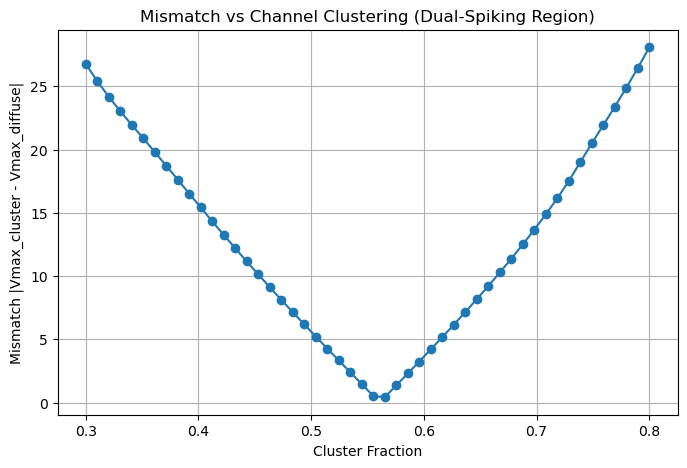

In [35]:
valid_cluster_values = [cluster_values[i] for i in both_spike_indices]

plt.figure(figsize=(8, 5))
plt.plot(valid_cluster_values, mismatch_values, marker='o')
plt.xlabel("Cluster Fraction")
plt.ylabel("Mismatch |Vmax_cluster - Vmax_diffuse|")
plt.title("Mismatch vs Channel Clustering (Dual-Spiking Region)")
plt.grid(True)
plt.savefig("Mismatch vs Channel Clustering (Dual-Spiking Region).png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
def first_spike_time(time, V, threshold=0):
    for t, v in zip(time, V):
        if v > threshold:
            return t
    return None

In [37]:
delay_values = []
valid_delay_cluster_values = []

for f in cluster_values:
    time, V_c, V_d = run_two_compartment_simulation(cluster_fraction=f)

    t_cluster = first_spike_time(time, V_c, threshold=0)
    t_diffuse = first_spike_time(time, V_d, threshold=0)

    if t_cluster is not None and t_diffuse is not None:
        delay = t_diffuse - t_cluster
        delay_values.append(delay)
        valid_delay_cluster_values.append(f)

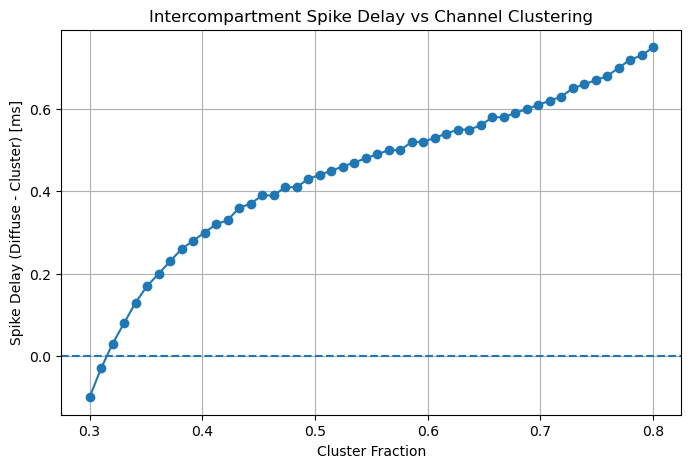

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(valid_delay_cluster_values, delay_values, marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel("Cluster Fraction")
plt.ylabel("Spike Delay (Diffuse - Cluster) [ms]")
plt.title("Intercompartment Spike Delay vs Channel Clustering")
plt.grid(True)
plt.savefig("Intercompartment Spike Delay vs Channel Clustering.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
tradeoff_mismatch = []
tradeoff_delay = []
tradeoff_cluster_values = []

for f in cluster_values:
    time, V_c, V_d = run_two_compartment_simulation(cluster_fraction=f)

    # Spike times
    t_cluster = first_spike_time(time, V_c, threshold=0)
    t_diffuse = first_spike_time(time, V_d, threshold=0)

    # Max voltages
    Vc_max = max(V_c)
    Vd_max = max(V_d)

    # Only include points where both spike
    if t_cluster is not None and t_diffuse is not None:
        delay = t_diffuse - t_cluster
        mismatch = abs(Vc_max - Vd_max)

        tradeoff_delay.append(delay)
        tradeoff_mismatch.append(mismatch)
        tradeoff_cluster_values.append(f)

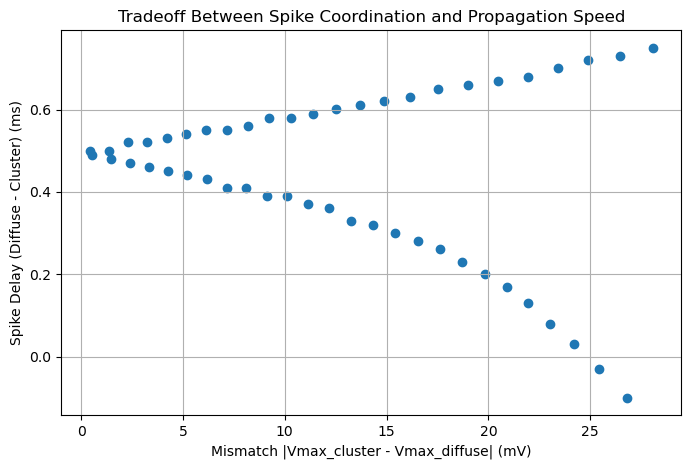

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(tradeoff_mismatch, tradeoff_delay)

plt.xlabel("Mismatch |Vmax_cluster - Vmax_diffuse| (mV)")
plt.ylabel("Spike Delay (Diffuse - Cluster) (ms)")
plt.title("Tradeoff Between Spike Coordination and Propagation Speed")

plt.grid(True)
plt.savefig("Tradeoff Between Spike Coordination and Propagation Speed.png", dpi=300, bbox_inches="tight")
plt.show()

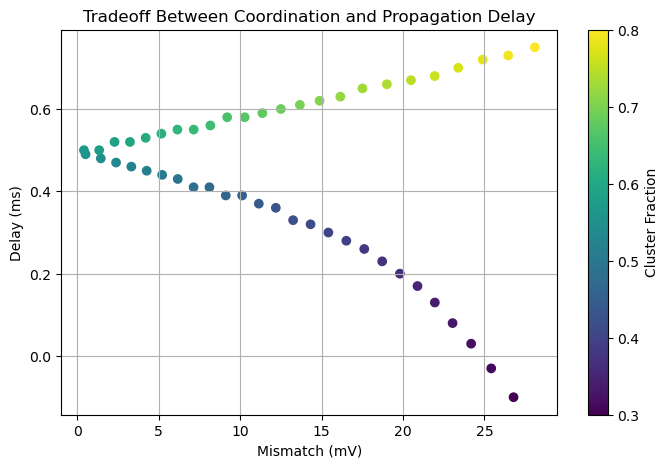

In [71]:
plt.figure(figsize=(8, 5))
sc = plt.scatter(tradeoff_mismatch, tradeoff_delay, c=tradeoff_cluster_values)

plt.xlabel("Mismatch (mV)")
plt.ylabel("Delay (ms)")
plt.title("Tradeoff Between Coordination and Propagation Delay")

plt.colorbar(sc, label="Cluster Fraction")
plt.grid(True)
plt.savefig("Tradeoff between coordination and propagation delay.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
feasible_cluster_values = []

for f in cluster_values:
    time, V_c, V_d = run_two_compartment_simulation(cluster_fraction=f)

    t_cluster = first_spike_time(time, V_c, threshold=0)
    t_diffuse = first_spike_time(time, V_d, threshold=0)

    # Check both compartments spike
    if t_cluster is not None and t_diffuse is not None:
        delay = t_diffuse - t_cluster

        # Apply delay constraint
        if delay < 0.5:
            feasible_cluster_values.append(f)

# Print result
if feasible_cluster_values:
    print("Feasible cluster_fraction range:")
    print(min(feasible_cluster_values), "to", max(feasible_cluster_values))
else:
    print("No feasible region found.")

Feasible cluster_fraction range:
0.3 to 0.5551020408163265


In [43]:
def run_two_compartment_simulation(
    cluster_fraction,
    T=50,
    dt=0.01,
    g_Na_total=120.0,
    g_c=1.0,
    I_ext_amp=20.0
):
    steps = int(T / dt)
    time = np.linspace(0, T, steps)

    # Fixed total sodium conductance, redistributed by cluster_fraction
    g_Na_cluster = g_Na_total * cluster_fraction
    g_Na_diffuse = g_Na_total * (1 - cluster_fraction)

    # Other membrane parameters
    C_m = 1.0
    g_K = 36.0
    g_L = 0.3

    E_Na = 50.0
    E_K = -77.0
    E_L = -54.4

    # Initial voltages
    V_cluster = -65.0
    V_diffuse = -65.0

    # Initial gating variables
    m_cluster, h_cluster, n_cluster = 0.05, 0.60, 0.32
    m_diffuse, h_diffuse, n_diffuse = 0.05, 0.60, 0.32

    # Storage
    V_cluster_history = []
    V_diffuse_history = []

    for i in range(steps):
        # Cluster rates
        alpha_m_c = 0.1 * (V_cluster + 40) / (1 - np.exp(-(V_cluster + 40) / 10))
        beta_m_c = 4.0 * np.exp(-(V_cluster + 65) / 18)

        alpha_h_c = 0.07 * np.exp(-(V_cluster + 65) / 20)
        beta_h_c = 1 / (1 + np.exp(-(V_cluster + 35) / 10))

        alpha_n_c = 0.01 * (V_cluster + 55) / (1 - np.exp(-(V_cluster + 55) / 10))
        beta_n_c = 0.125 * np.exp(-(V_cluster + 65) / 80)

        # Diffuse rates
        alpha_m_d = 0.1 * (V_diffuse + 40) / (1 - np.exp(-(V_diffuse + 40) / 10))
        beta_m_d = 4.0 * np.exp(-(V_diffuse + 65) / 18)

        alpha_h_d = 0.07 * np.exp(-(V_diffuse + 65) / 20)
        beta_h_d = 1 / (1 + np.exp(-(V_diffuse + 35) / 10))

        alpha_n_d = 0.01 * (V_diffuse + 55) / (1 - np.exp(-(V_diffuse + 55) / 10))
        beta_n_d = 0.125 * np.exp(-(V_diffuse + 65) / 80)

        # Update gating variables
        m_cluster += (alpha_m_c * (1 - m_cluster) - beta_m_c * m_cluster) * dt
        h_cluster += (alpha_h_c * (1 - h_cluster) - beta_h_c * h_cluster) * dt
        n_cluster += (alpha_n_c * (1 - n_cluster) - beta_n_c * n_cluster) * dt

        m_diffuse += (alpha_m_d * (1 - m_diffuse) - beta_m_d * m_diffuse) * dt
        h_diffuse += (alpha_h_d * (1 - h_diffuse) - beta_h_d * h_diffuse) * dt
        n_diffuse += (alpha_n_d * (1 - n_diffuse) - beta_n_d * n_diffuse) * dt

        # Currents
        I_Na_c = g_Na_cluster * (m_cluster**3) * h_cluster * (V_cluster - E_Na)
        I_K_c = g_K * (n_cluster**4) * (V_cluster - E_K)
        I_L_c = g_L * (V_cluster - E_L)

        I_Na_d = g_Na_diffuse * (m_diffuse**3) * h_diffuse * (V_diffuse - E_Na)
        I_K_d = g_K * (n_diffuse**4) * (V_diffuse - E_K)
        I_L_d = g_L * (V_diffuse - E_L)

        I_couple = g_c * (V_diffuse - V_cluster)

        # Stimulus to cluster compartment only
        I_ext = I_ext_amp if 5 <= time[i] < 7 else 0

        # Voltage updates
        V_cluster += (-(I_Na_c + I_K_c + I_L_c) + I_ext + I_couple) / C_m * dt
        V_diffuse += (-(I_Na_d + I_K_d + I_L_d) - I_couple) / C_m * dt

        # Store
        V_cluster_history.append(V_cluster)
        V_diffuse_history.append(V_diffuse)

    return time, V_cluster_history, V_diffuse_history

In [44]:
def check_spike(V, threshold=0):
    return max(V) > threshold


def first_spike_time(time, V, threshold=0):
    for t, v in zip(time, V):
        if v > threshold:
            return t
    return None


def analyze_parameter_setting(
    cluster_values,
    g_c=1.0,
    g_Na_total=120.0,
    I_ext_amp=20.0,
    delay_threshold=0.5
):
    cluster_success = []
    diffuse_success = []
    cluster_max = []
    diffuse_max = []
    delay_values = []
    valid_delay_cluster_values = []

    both_spike_indices = []
    mismatch_values = []

    tradeoff_mismatch = []
    tradeoff_delay = []
    tradeoff_cluster_values = []

    feasible_cluster_values = []

    for i, f in enumerate(cluster_values):
        time, V_c, V_d = run_two_compartment_simulation(
            cluster_fraction=f,
            g_c=g_c,
            g_Na_total=g_Na_total,
            I_ext_amp=I_ext_amp
        )

        cluster_spike = int(check_spike(V_c))
        diffuse_spike = int(check_spike(V_d))

        cluster_success.append(cluster_spike)
        diffuse_success.append(diffuse_spike)

        Vc_max = max(V_c)
        Vd_max = max(V_d)

        cluster_max.append(Vc_max)
        diffuse_max.append(Vd_max)

        t_cluster = first_spike_time(time, V_c, threshold=0)
        t_diffuse = first_spike_time(time, V_d, threshold=0)

        if t_cluster is not None and t_diffuse is not None:
            delay = t_diffuse - t_cluster
            mismatch = abs(Vc_max - Vd_max)

            delay_values.append(delay)
            valid_delay_cluster_values.append(f)

            both_spike_indices.append(i)
            mismatch_values.append(mismatch)

            tradeoff_delay.append(delay)
            tradeoff_mismatch.append(mismatch)
            tradeoff_cluster_values.append(f)

            if delay < delay_threshold:
                feasible_cluster_values.append(f)

    # amplitude optimum
    if len(both_spike_indices) > 0:
        best_local_index = mismatch_values.index(min(mismatch_values))
        best_global_index = both_spike_indices[best_local_index]

        optimal_cluster_fraction = cluster_values[best_global_index]
        optimal_cluster_max = cluster_max[best_global_index]
        optimal_diffuse_max = diffuse_max[best_global_index]
        optimal_mismatch = mismatch_values[best_local_index]
    else:
        optimal_cluster_fraction = None
        optimal_cluster_max = None
        optimal_diffuse_max = None
        optimal_mismatch = None

    # feasible region
    if len(feasible_cluster_values) > 0:
        feasible_min = min(feasible_cluster_values)
        feasible_max = max(feasible_cluster_values)
    else:
        feasible_min = None
        feasible_max = None

    return {
        "cluster_values": cluster_values,
        "cluster_success": cluster_success,
        "diffuse_success": diffuse_success,
        "cluster_max": cluster_max,
        "diffuse_max": diffuse_max,
        "delay_values": delay_values,
        "valid_delay_cluster_values": valid_delay_cluster_values,
        "both_spike_indices": both_spike_indices,
        "mismatch_values": mismatch_values,
        "tradeoff_mismatch": tradeoff_mismatch,
        "tradeoff_delay": tradeoff_delay,
        "tradeoff_cluster_values": tradeoff_cluster_values,
        "feasible_cluster_values": feasible_cluster_values,
        "optimal_cluster_fraction": optimal_cluster_fraction,
        "optimal_cluster_max": optimal_cluster_max,
        "optimal_diffuse_max": optimal_diffuse_max,
        "optimal_mismatch": optimal_mismatch,
        "feasible_min": feasible_min,
        "feasible_max": feasible_max,
        "g_c": g_c,
        "g_Na_total": g_Na_total,
        "I_ext_amp": I_ext_amp,
        "delay_threshold": delay_threshold
    }

In [45]:
def plot_analysis_results_combined(results, title_suffix="", save_name=None):
    cluster_values = results["cluster_values"]
    cluster_success = results["cluster_success"]
    diffuse_success = results["diffuse_success"]
    cluster_max = results["cluster_max"]
    diffuse_max = results["diffuse_max"]
    both_spike_indices = results["both_spike_indices"]
    mismatch_values = results["mismatch_values"]
    delay_values = results["delay_values"]
    valid_delay_cluster_values = results["valid_delay_cluster_values"]
    tradeoff_mismatch = results["tradeoff_mismatch"]
    tradeoff_delay = results["tradeoff_delay"]
    tradeoff_cluster_values = results["tradeoff_cluster_values"]

    fig, axs = plt.subplots(3, 2, figsize=(12, 14))
    axs = axs.flatten()

    # 1. Spike success
    axs[0].plot(cluster_values, cluster_success, marker='o', label="Cluster")
    axs[0].plot(cluster_values, diffuse_success, marker='s', label="Diffuse")
    axs[0].set_title("Spike Success")
    axs[0].set_xlabel("Cluster Fraction")
    axs[0].set_ylabel("Spike Success")
    axs[0].legend()
    axs[0].grid(True)

    # 2. Max voltage
    axs[1].plot(cluster_values, cluster_max, marker='o', label="Cluster")
    axs[1].plot(cluster_values, diffuse_max, marker='s', label="Diffuse")
    axs[1].axhline(0, linestyle='--', label="Spike Threshold (0 mV)")
    axs[1].set_title("Max Voltage")
    axs[1].set_xlabel("Cluster Fraction")
    axs[1].set_ylabel("Max Voltage (mV)")
    axs[1].legend()
    axs[1].grid(True)

    # 3. Mismatch curve
    valid_cluster_values = [cluster_values[i] for i in both_spike_indices]
    axs[2].plot(valid_cluster_values, mismatch_values, marker='o')
    axs[2].set_title("Mismatch")
    axs[2].set_xlabel("Cluster Fraction")
    axs[2].set_ylabel("|Vmax_cluster - Vmax_diffuse|")
    axs[2].grid(True)

    # 4. Delay curve
    axs[3].plot(valid_delay_cluster_values, delay_values, marker='o')
    axs[3].axhline(0, linestyle='--')
    axs[3].set_title("Delay")
    axs[3].set_xlabel("Cluster Fraction")
    axs[3].set_ylabel("Spike Delay (ms)")
    axs[3].grid(True)

    # 5. Tradeoff plot
    sc = axs[4].scatter(tradeoff_mismatch, tradeoff_delay, c=tradeoff_cluster_values)
    axs[4].set_title("Tradeoff: Coordination vs Speed")
    axs[4].set_xlabel("Mismatch |Vmax_cluster - Vmax_diffuse| (mV)")
    axs[4].set_ylabel("Spike Delay (Diffuse - Cluster) (ms)")
    axs[4].grid(True)

    cbar = fig.colorbar(sc, ax=axs[4])
    cbar.set_label("Cluster Fraction")

    # Remove empty 6th panel
    fig.delaxes(axs[5])

    fig.suptitle(f"Analysis Summary {title_suffix}", fontsize=16)
    plt.tight_layout()

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()


def print_summary(results, label="Condition"):
    print(f"--- {label} ---")
    print("g_c =", results["g_c"])
    print("g_Na_total =", results["g_Na_total"])
    print("I_ext_amp =", results["I_ext_amp"])
    print("delay_threshold =", results["delay_threshold"])
    print()

    print("Amplitude optimum cluster_fraction:", results["optimal_cluster_fraction"])
    print("Cluster max voltage at optimum:", results["optimal_cluster_max"])
    print("Diffuse max voltage at optimum:", results["optimal_diffuse_max"])
    print("Voltage mismatch at optimum:", results["optimal_mismatch"])
    print()

    if results["feasible_min"] is not None:
        print("Feasible cluster_fraction range:")
        print(results["feasible_min"], "to", results["feasible_max"])
    else:
        print("No feasible region found.")
    print()

--- Baseline ---
g_c = 1.0
g_Na_total = 120.0
I_ext_amp = 20.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5656565656565657
Cluster max voltage at optimum: 27.436623848199602
Diffuse max voltage at optimum: 26.986813268860004
Voltage mismatch at optimum: 0.4498105793395979

Feasible cluster_fraction range:
0.27272727272727276 to 0.5555555555555556



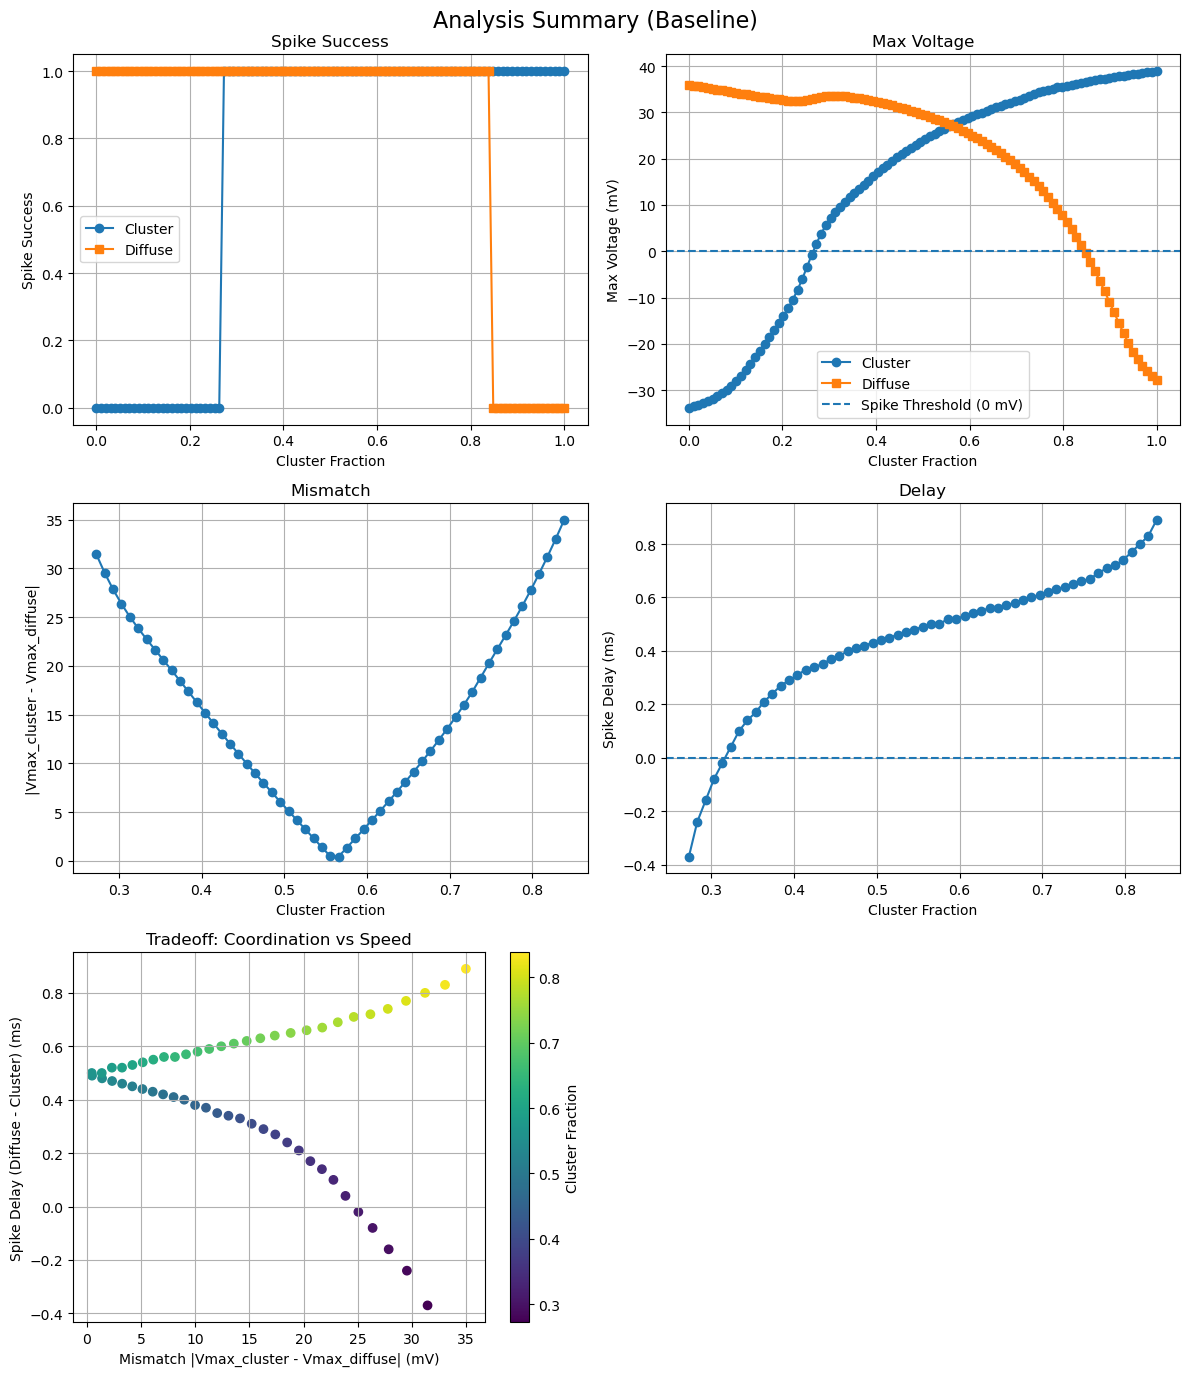

In [46]:
cluster_values = np.linspace(0.0, 1.0, 100)
delay_threshold = 0.5

baseline_results = analyze_parameter_setting(
    cluster_values=cluster_values,
    g_c=1.0,
    g_Na_total=120.0,
    I_ext_amp=20.0,
    delay_threshold=delay_threshold
)

print_summary(baseline_results, label="Baseline")
plot_analysis_results_combined(
    baseline_results,
    title_suffix="(Baseline)",
    save_name="baseline_analysis_summary.png"
)

In [47]:
coupling_conditions = {
    "Low coupling": 0.5,
    "Baseline coupling": 1.0,
    "High coupling": 1.5
}

coupling_results = {}

for label, g_c_val in coupling_conditions.items():
    results = analyze_parameter_setting(
        cluster_values=cluster_values,
        g_c=g_c_val,
        g_Na_total=120.0,
        I_ext_amp=20.0,
        delay_threshold=delay_threshold
    )
    coupling_results[label] = results
    print_summary(results, label=label)

--- Low coupling ---
g_c = 0.5
g_Na_total = 120.0
I_ext_amp = 20.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5252525252525253
Cluster max voltage at optimum: 28.07189005676255
Diffuse max voltage at optimum: 28.131468611901553
Voltage mismatch at optimum: 0.05957855513900512

Feasible cluster_fraction range:
0.27272727272727276 to 0.2828282828282829

--- Baseline coupling ---
g_c = 1.0
g_Na_total = 120.0
I_ext_amp = 20.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5656565656565657
Cluster max voltage at optimum: 27.436623848199602
Diffuse max voltage at optimum: 26.986813268860004
Voltage mismatch at optimum: 0.4498105793395979

Feasible cluster_fraction range:
0.27272727272727276 to 0.5555555555555556

--- High coupling ---
g_c = 1.5
g_Na_total = 120.0
I_ext_amp = 20.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5757575757575758
Cluster max voltage at optimum: 26.724498805856726
Diffuse max voltage at optimum: 26.657396435896096
Vol

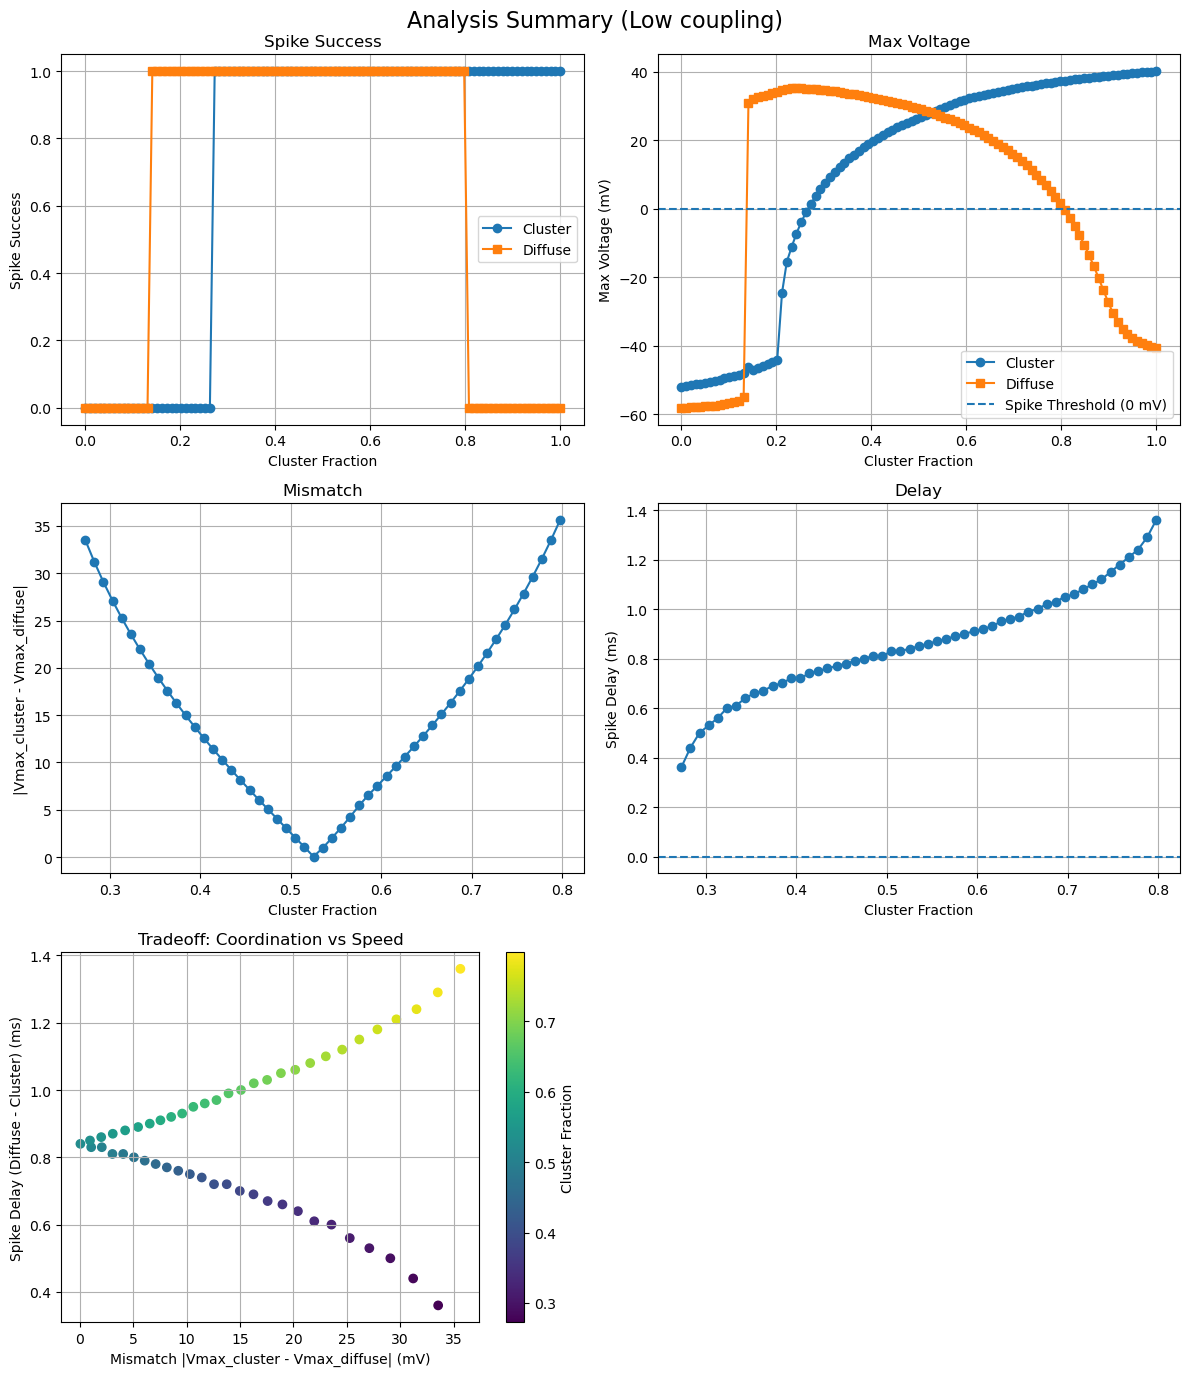

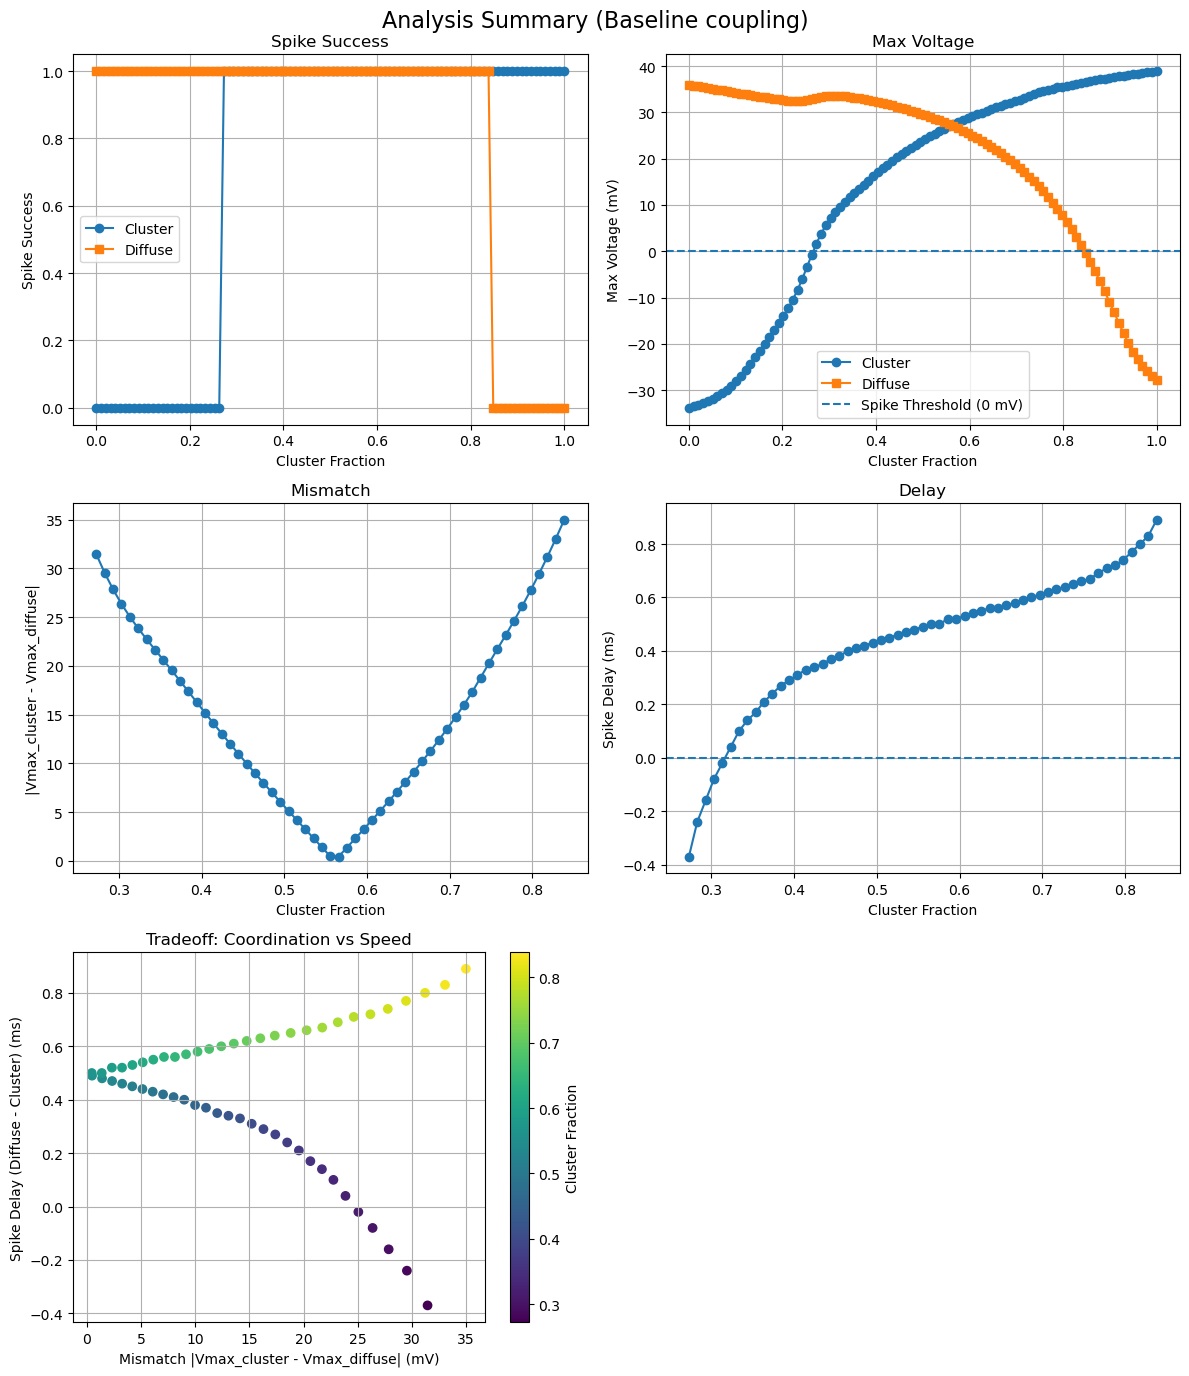

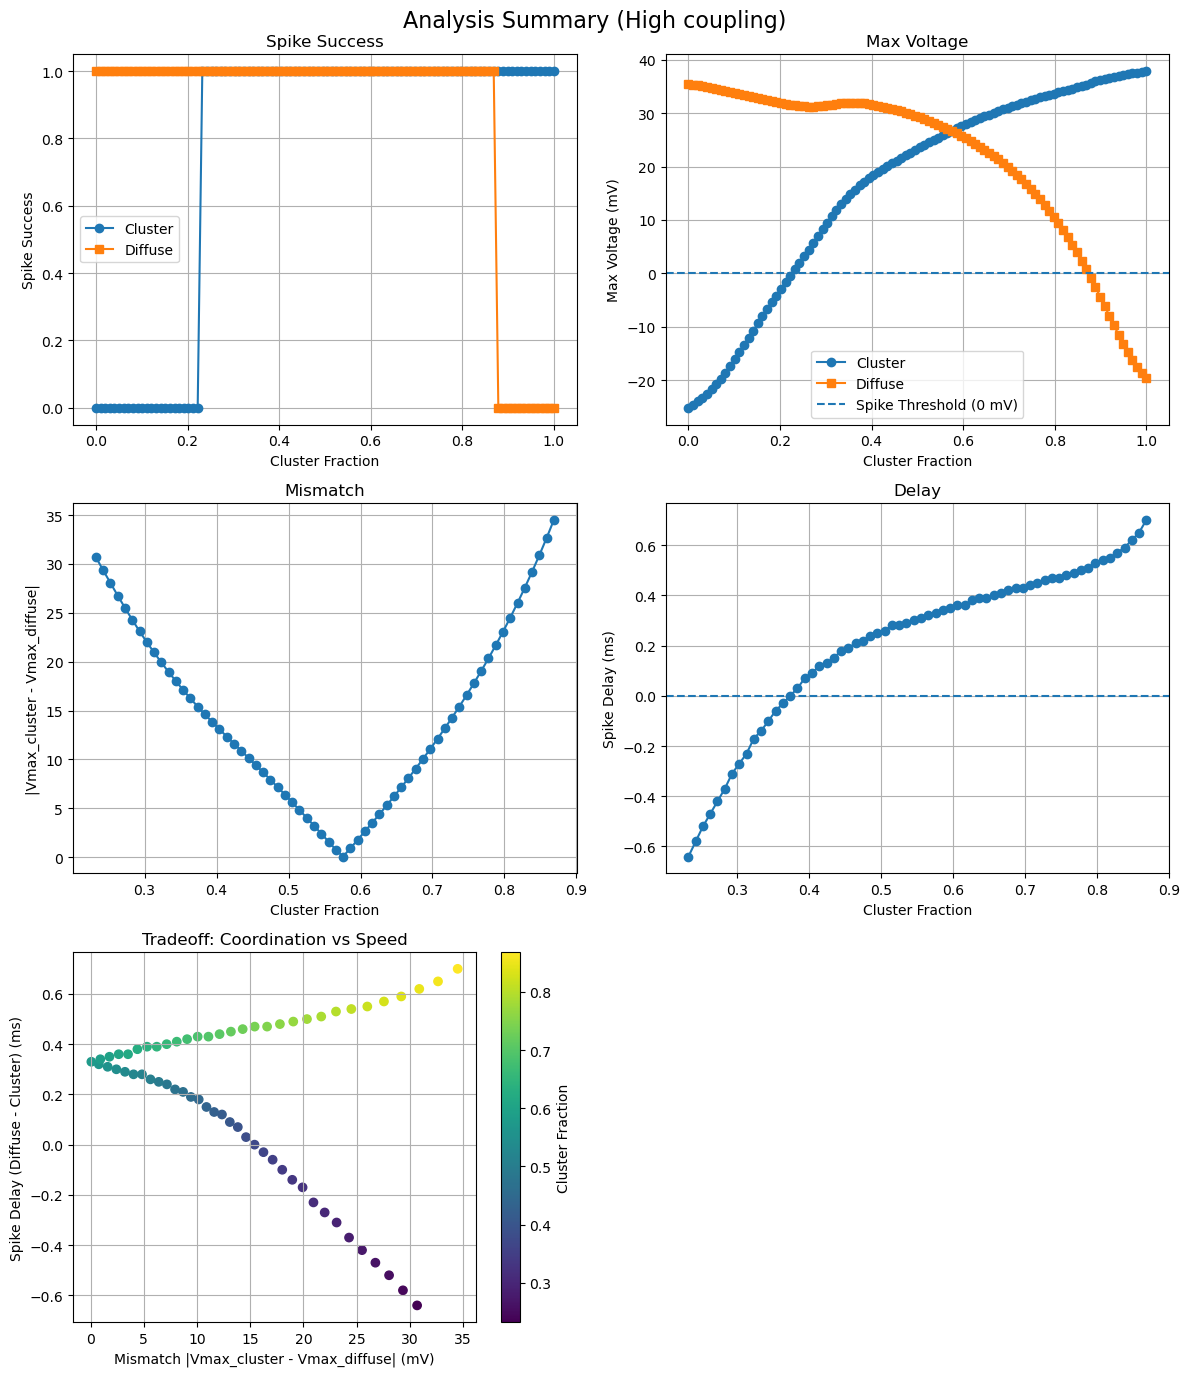

In [48]:
for label, results in coupling_results.items():
    safe_label = label.lower().replace(" ", "_")
    plot_analysis_results_combined(
        results,
        title_suffix=f"({label})",
        save_name=f"{safe_label}_analysis_summary.png"
    )

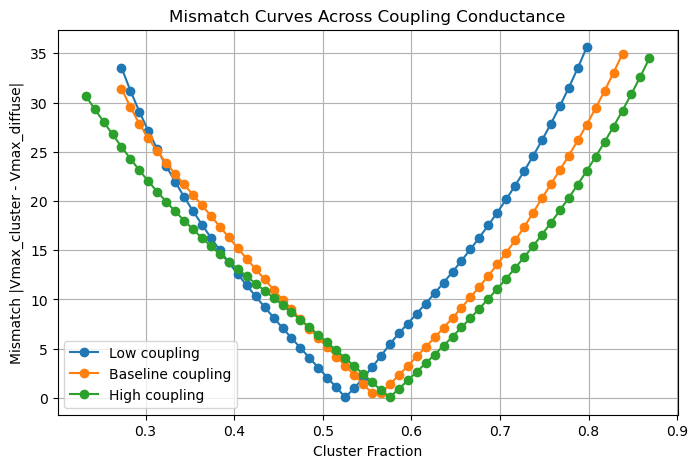

In [49]:
plt.figure(figsize=(8, 5))

for label, results in coupling_results.items():
    valid_cluster_values = [results["cluster_values"][i] for i in results["both_spike_indices"]]
    plt.plot(valid_cluster_values, results["mismatch_values"], marker='o', label=label)

plt.xlabel("Cluster Fraction")
plt.ylabel("Mismatch |Vmax_cluster - Vmax_diffuse|")
plt.title("Mismatch Curves Across Coupling Conductance")
plt.legend()
plt.grid(True)
plt.savefig("coupling_mismatch_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

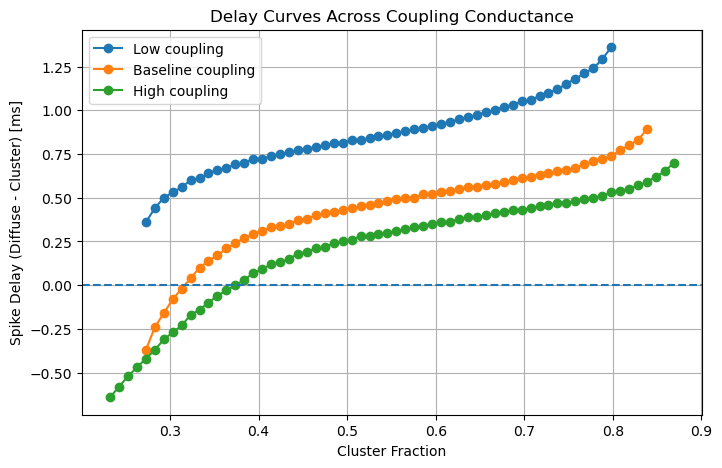

In [50]:
plt.figure(figsize=(8, 5))

for label, results in coupling_results.items():
    plt.plot(
        results["valid_delay_cluster_values"],
        results["delay_values"],
        marker='o',
        label=label
    )

plt.axhline(0, linestyle='--')
plt.xlabel("Cluster Fraction")
plt.ylabel("Spike Delay (Diffuse - Cluster) [ms]")
plt.title("Delay Curves Across Coupling Conductance")
plt.legend()
plt.grid(True)
plt.savefig("coupling_delay_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
sodium_conditions = {
    "Low total sodium": 100.0,
    "Baseline total sodium": 120.0,
    "High total sodium": 140.0
}

sodium_results = {}

for label, gNa_val in sodium_conditions.items():
    results = analyze_parameter_setting(
        cluster_values=cluster_values,
        g_c=1.0,
        g_Na_total=gNa_val,
        I_ext_amp=20.0,
        delay_threshold=delay_threshold
    )
    sodium_results[label] = results
    print_summary(results, label=label)

--- Low total sodium ---
g_c = 1.0
g_Na_total = 100.0
I_ext_amp = 20.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5656565656565657
Cluster max voltage at optimum: 21.829004887460403
Diffuse max voltage at optimum: 21.39779024660556
Voltage mismatch at optimum: 0.4312146408548436

Feasible cluster_fraction range:
0.3434343434343435 to 0.5353535353535354

--- Baseline total sodium ---
g_c = 1.0
g_Na_total = 120.0
I_ext_amp = 20.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5656565656565657
Cluster max voltage at optimum: 27.436623848199602
Diffuse max voltage at optimum: 26.986813268860004
Voltage mismatch at optimum: 0.4498105793395979

Feasible cluster_fraction range:
0.27272727272727276 to 0.5555555555555556

--- High total sodium ---
g_c = 1.0
g_Na_total = 140.0
I_ext_amp = 20.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5555555555555556
Cluster max voltage at optimum: 30.857969039606743
Diffuse max voltage at optimum: 31.242403979

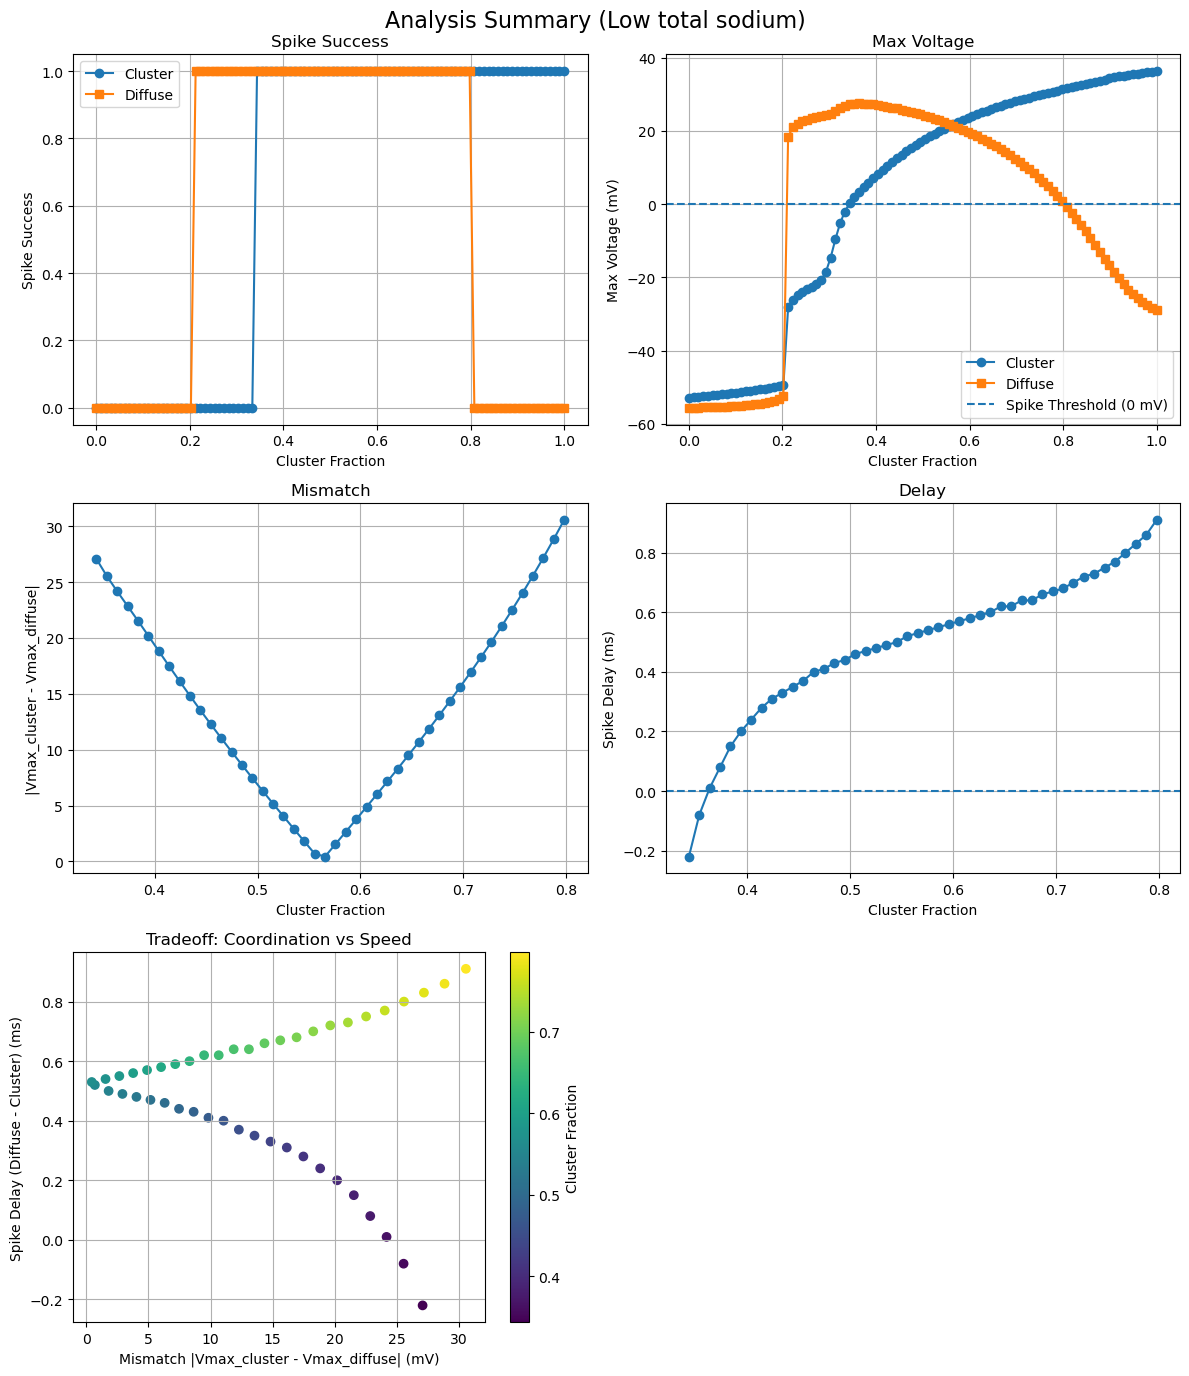

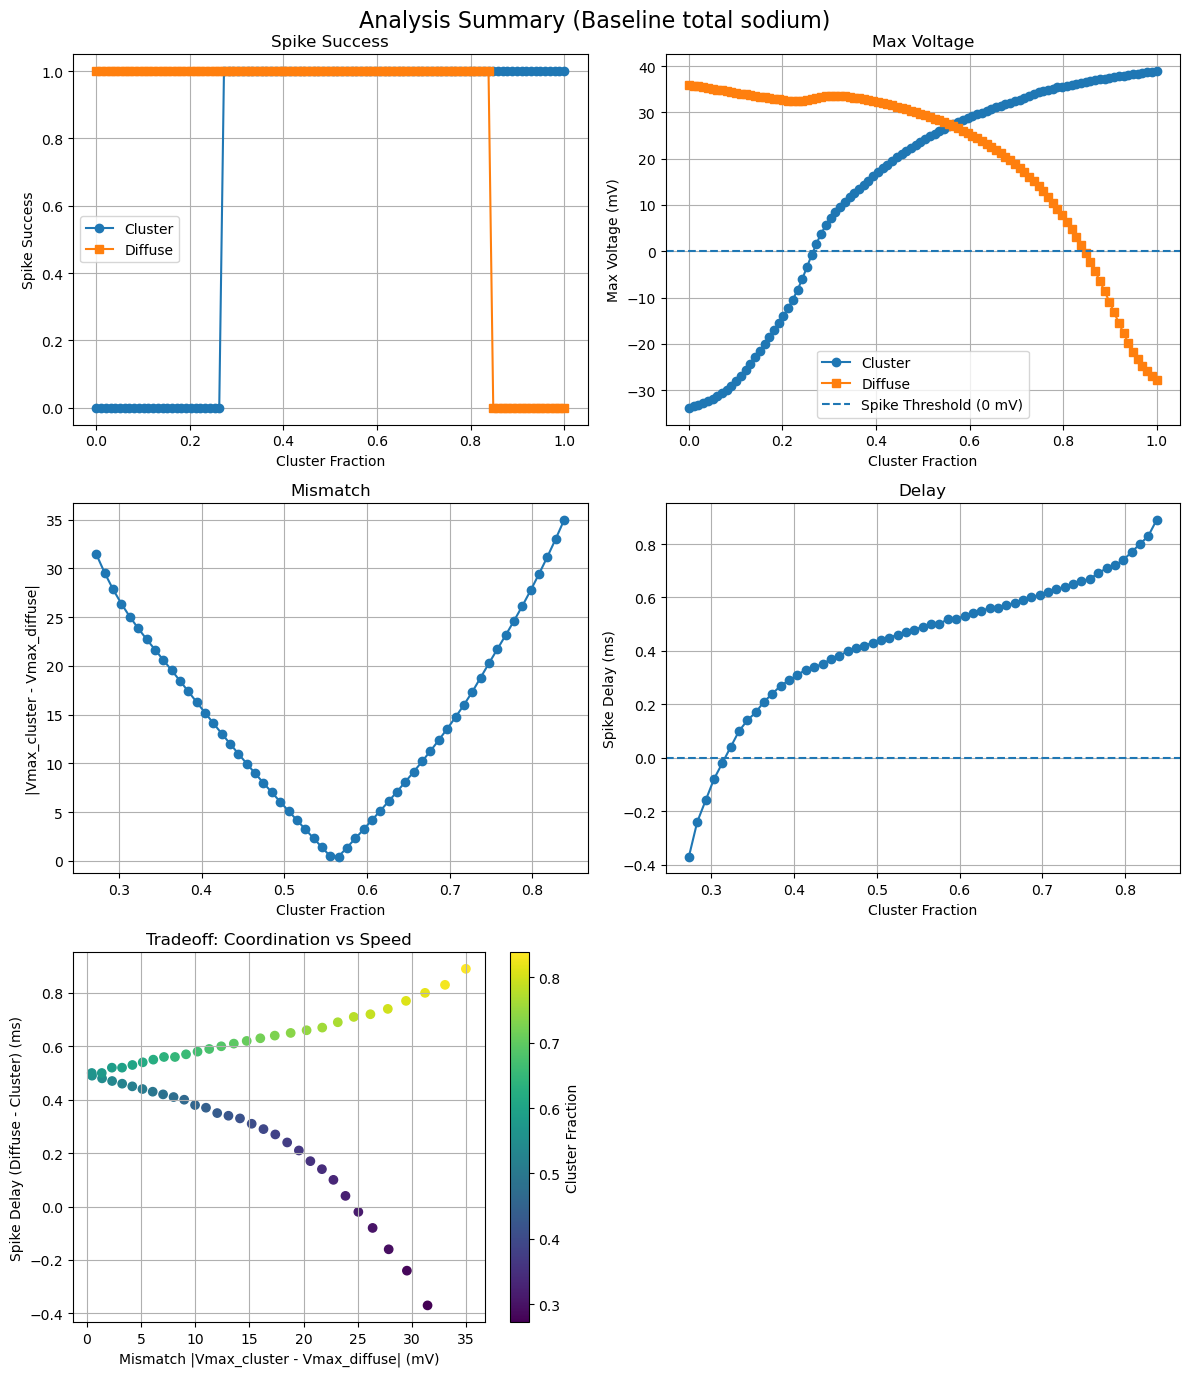

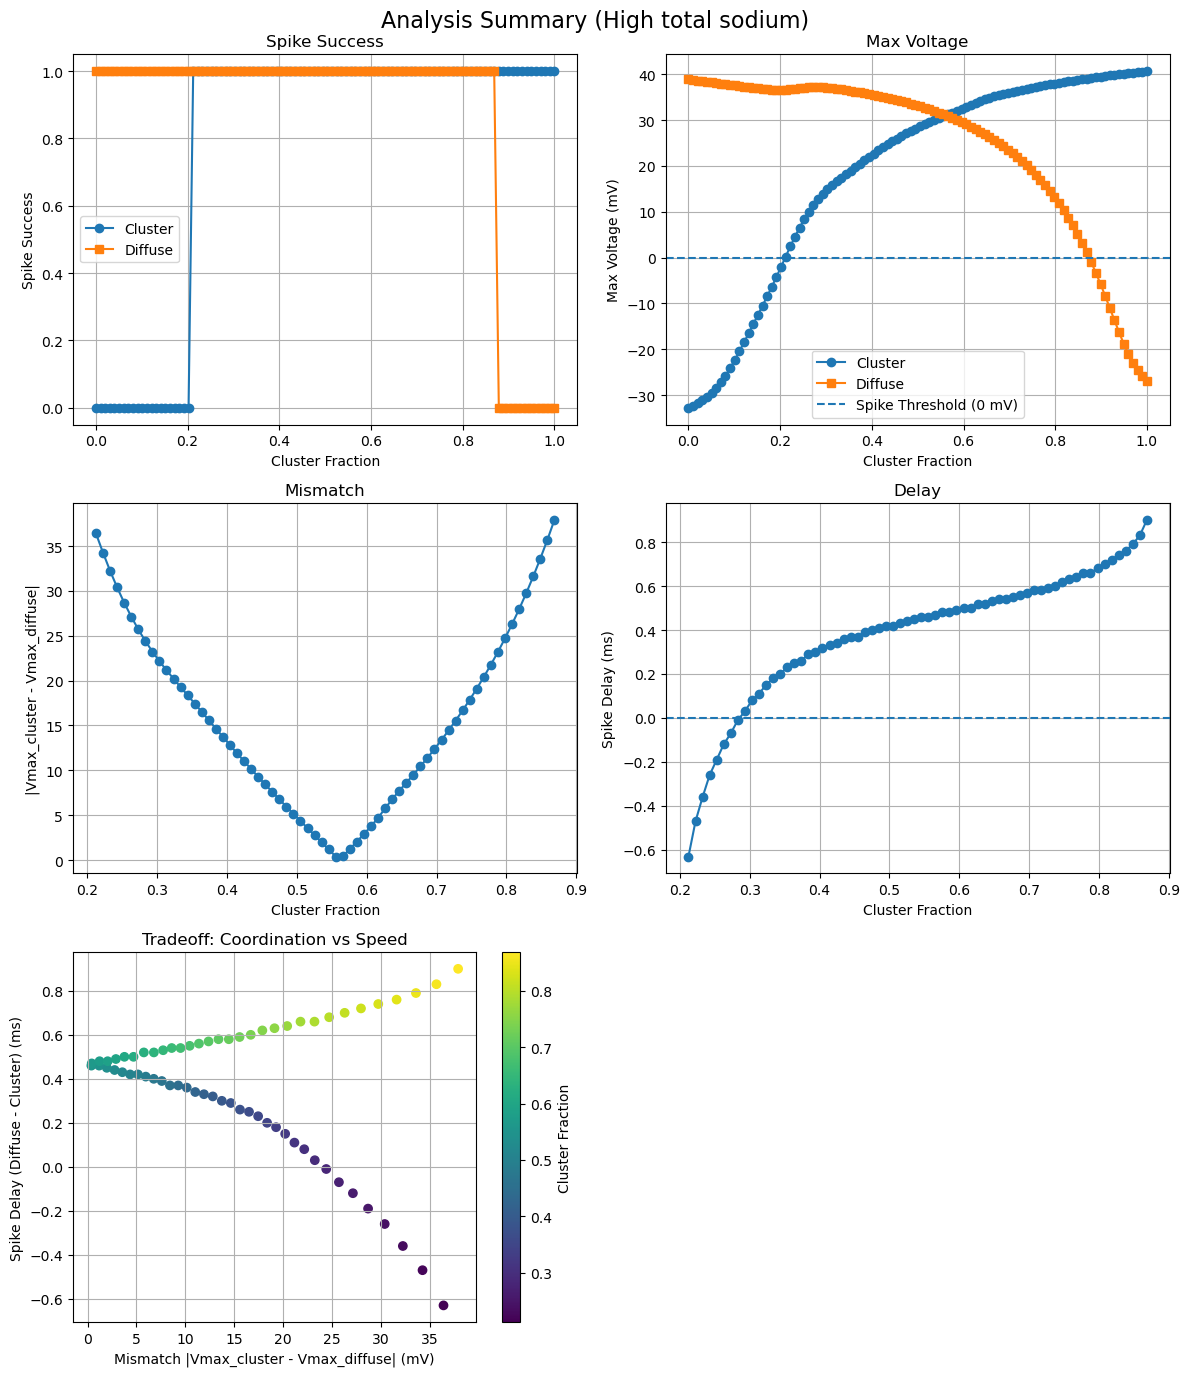

In [52]:
for label, results in sodium_results.items():
    safe_label = label.lower().replace(" ", "_")
    plot_analysis_results_combined(
        results,
        title_suffix=f"({label})",
        save_name=f"{safe_label}_analysis_summary.png"
    )

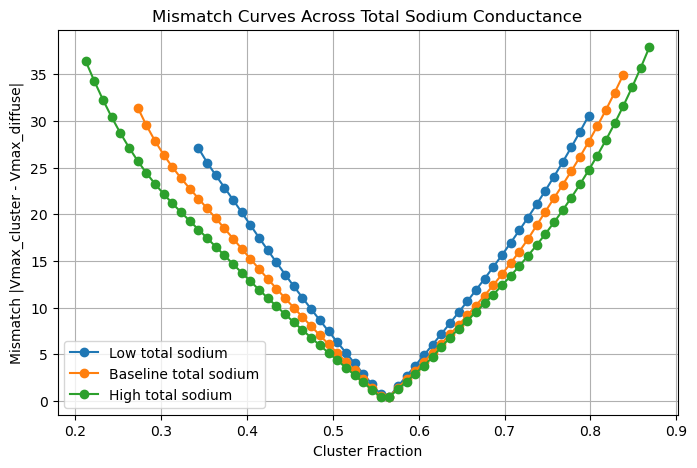

In [53]:
plt.figure(figsize=(8, 5))

for label, results in sodium_results.items():
    valid_cluster_values = [results["cluster_values"][i] for i in results["both_spike_indices"]]
    plt.plot(valid_cluster_values, results["mismatch_values"], marker='o', label=label)

plt.xlabel("Cluster Fraction")
plt.ylabel("Mismatch |Vmax_cluster - Vmax_diffuse|")
plt.title("Mismatch Curves Across Total Sodium Conductance")
plt.legend()
plt.grid(True)
plt.savefig("sodium_mismatch_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

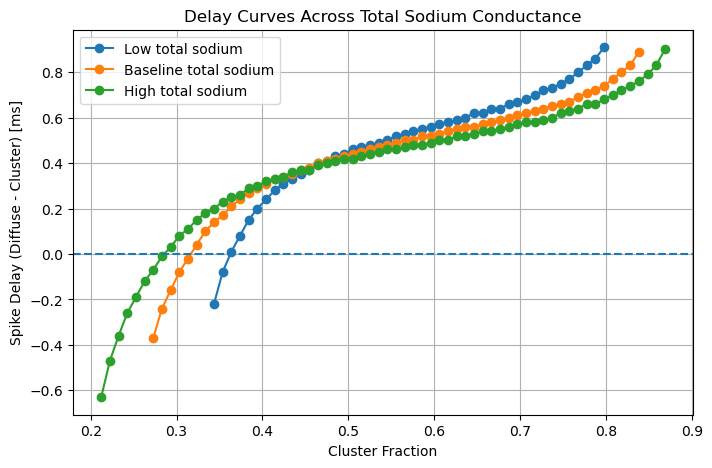

In [54]:
plt.figure(figsize=(8, 5))

for label, results in sodium_results.items():
    plt.plot(
        results["valid_delay_cluster_values"],
        results["delay_values"],
        marker='o',
        label=label
    )

plt.axhline(0, linestyle='--')
plt.xlabel("Cluster Fraction")
plt.ylabel("Spike Delay (Diffuse - Cluster) [ms]")
plt.title("Delay Curves Across Total Sodium Conductance")
plt.legend()
plt.grid(True)
plt.savefig("sodium_delay_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [55]:
input_conditions = {
    "Low input": 15.0,
    "Baseline input": 20.0,
    "High input": 25.0
}

input_results = {}

for label, I_val in input_conditions.items():
    results = analyze_parameter_setting(
        cluster_values=cluster_values,
        g_c=1.0,
        g_Na_total=120.0,
        I_ext_amp=I_val,
        delay_threshold=delay_threshold
    )
    input_results[label] = results
    print_summary(results, label=label)

--- Low input ---
g_c = 1.0
g_Na_total = 120.0
I_ext_amp = 15.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5757575757575758
Cluster max voltage at optimum: 25.548357973932042
Diffuse max voltage at optimum: 25.176533032153408
Voltage mismatch at optimum: 0.3718249417786339

Feasible cluster_fraction range:
0.42424242424242425 to 0.5757575757575758

--- Baseline input ---
g_c = 1.0
g_Na_total = 120.0
I_ext_amp = 20.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5656565656565657
Cluster max voltage at optimum: 27.436623848199602
Diffuse max voltage at optimum: 26.986813268860004
Voltage mismatch at optimum: 0.4498105793395979

Feasible cluster_fraction range:
0.27272727272727276 to 0.5555555555555556

--- High input ---
g_c = 1.0
g_Na_total = 120.0
I_ext_amp = 25.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5353535353535354
Cluster max voltage at optimum: 28.464213750333858
Diffuse max voltage at optimum: 28.852449528066636
Voltage mism

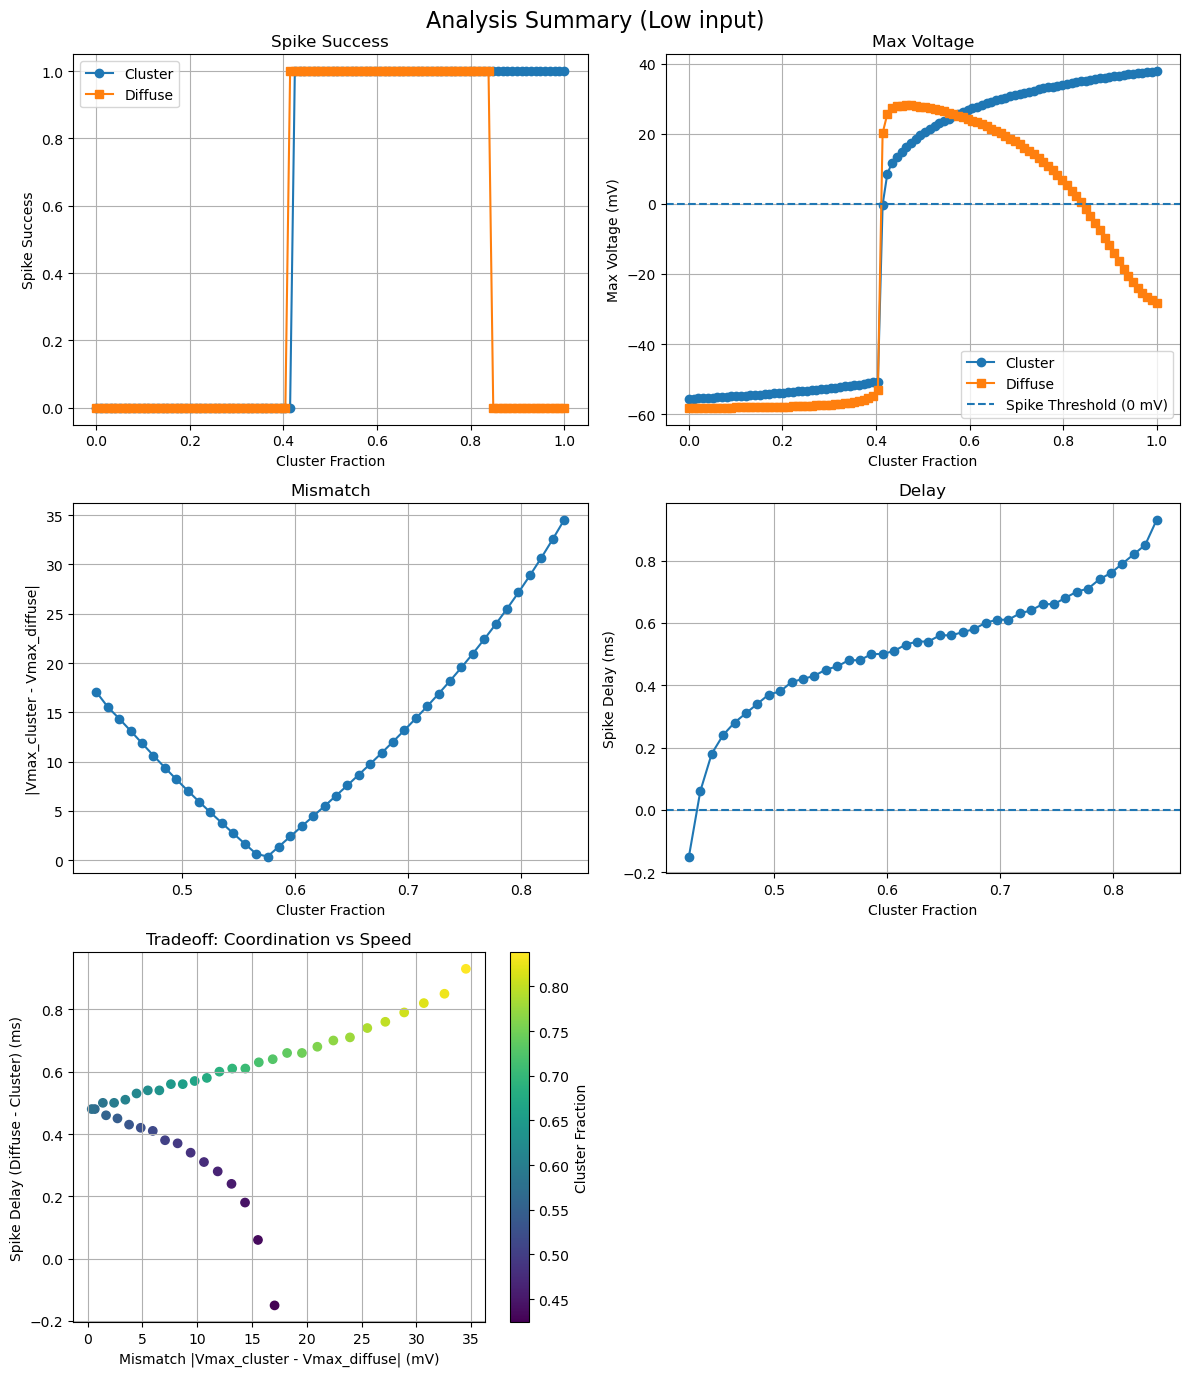

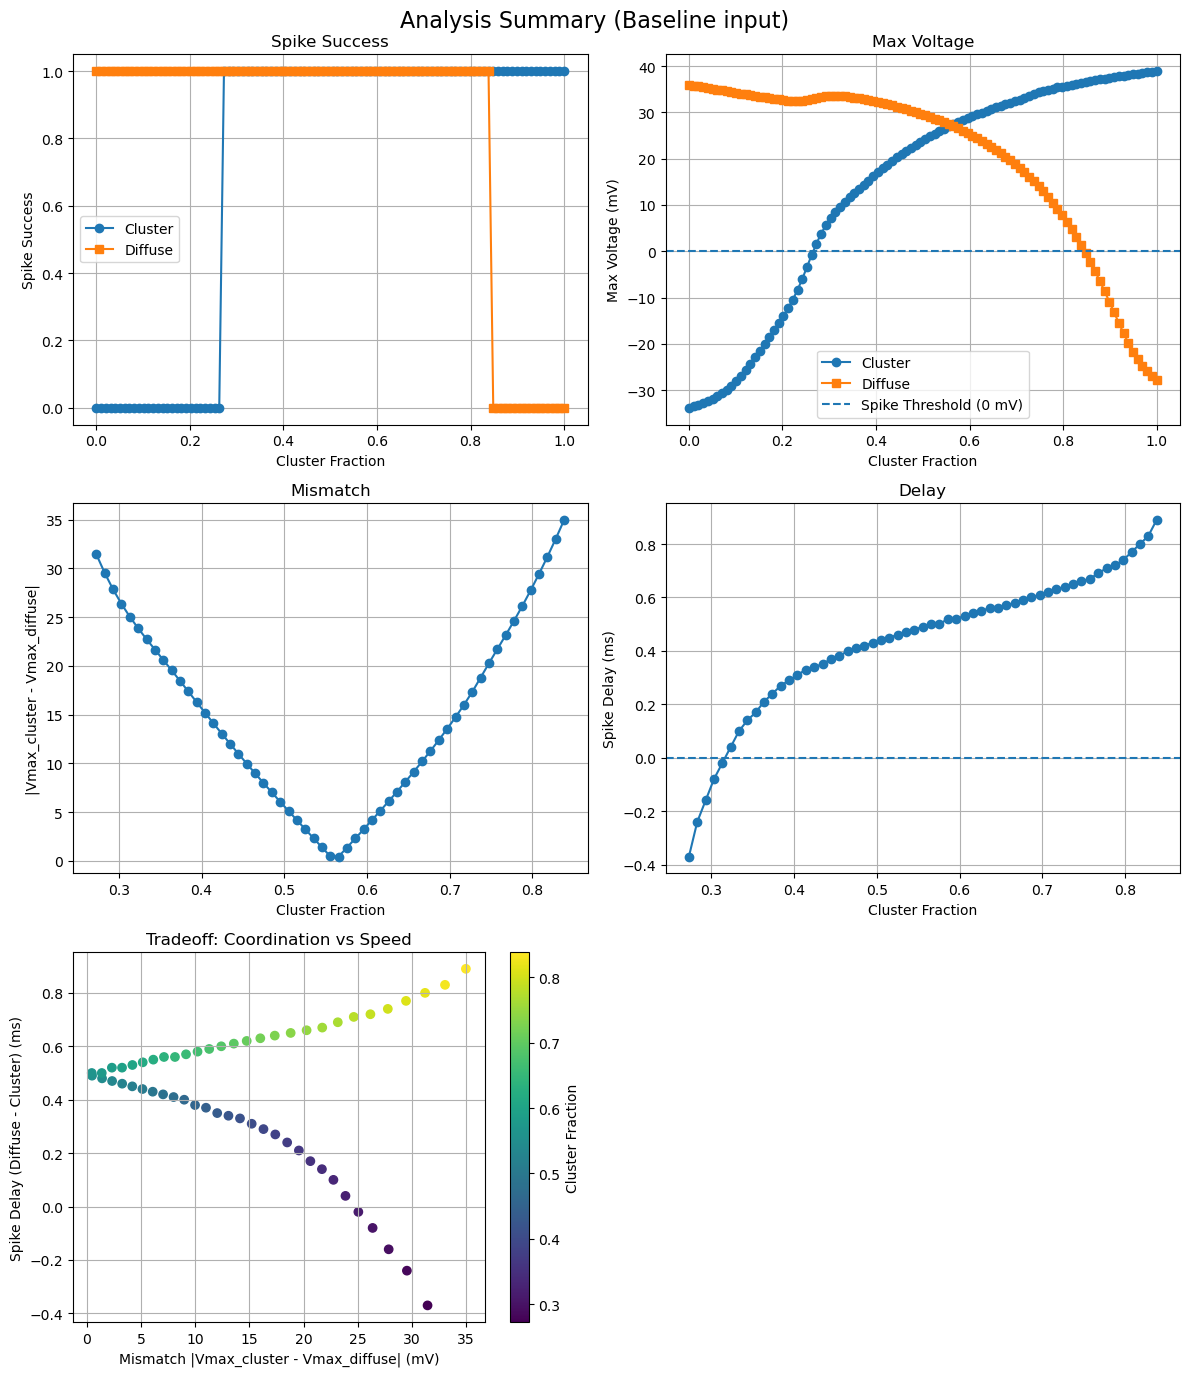

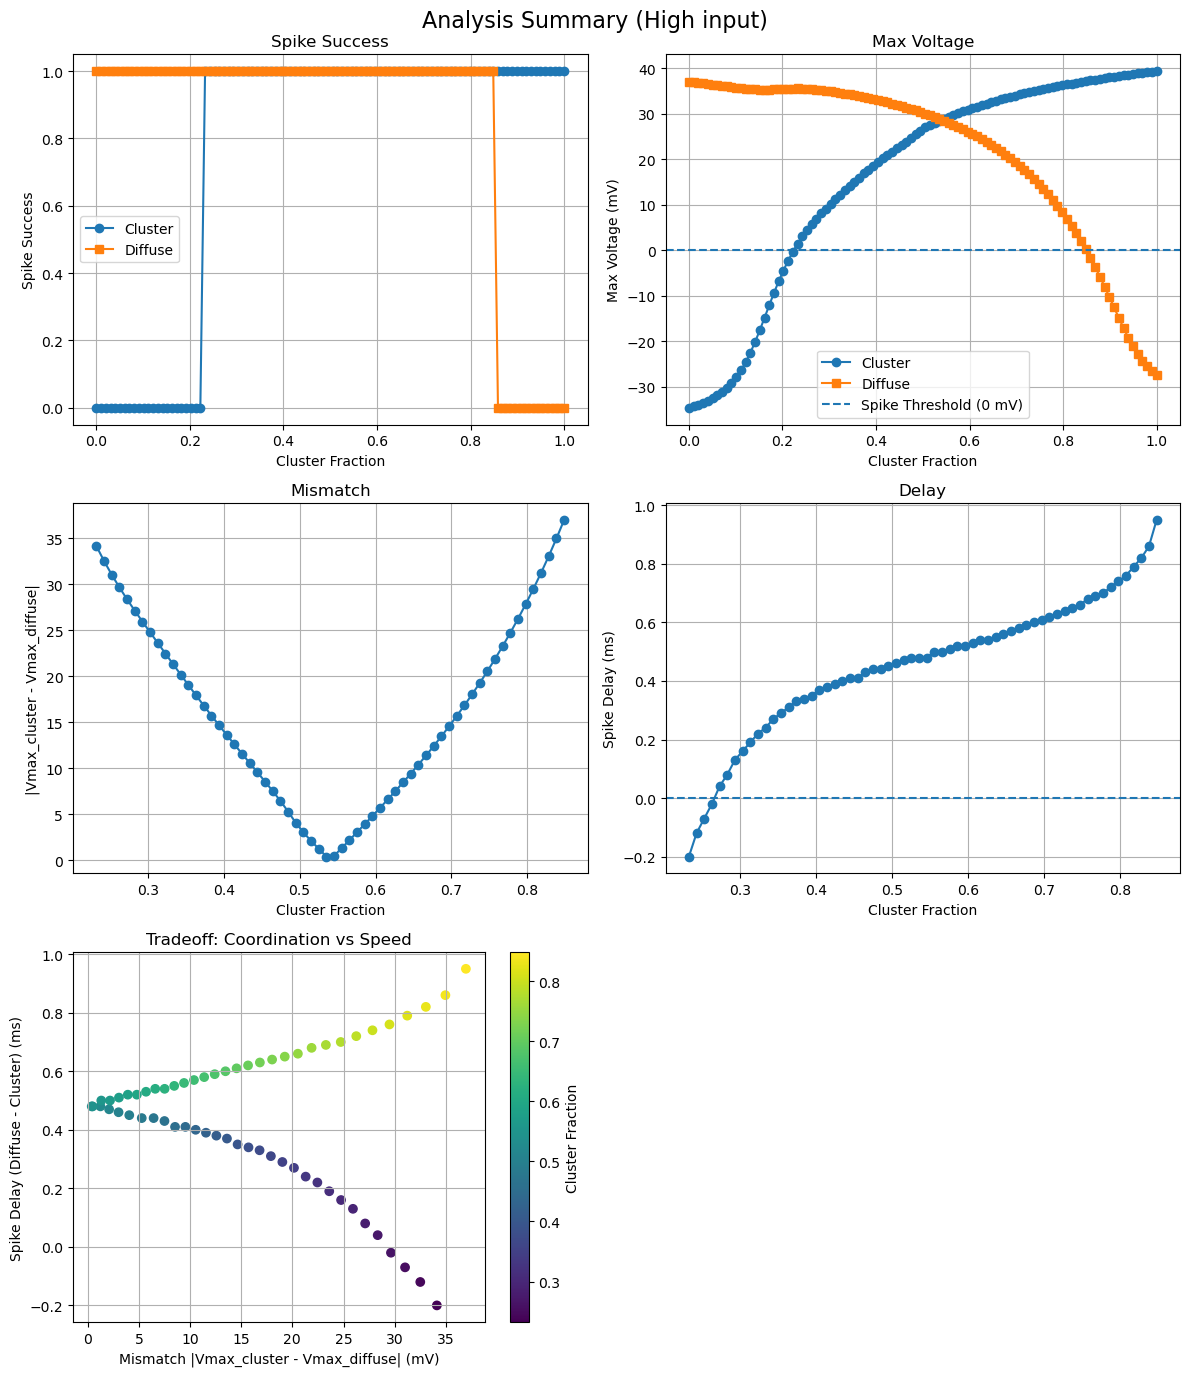

In [56]:
for label, results in input_results.items():
    safe_label = label.lower().replace(" ", "_")
    plot_analysis_results_combined(
        results,
        title_suffix=f"({label})",
        save_name=f"{safe_label}_analysis_summary.png"
    )

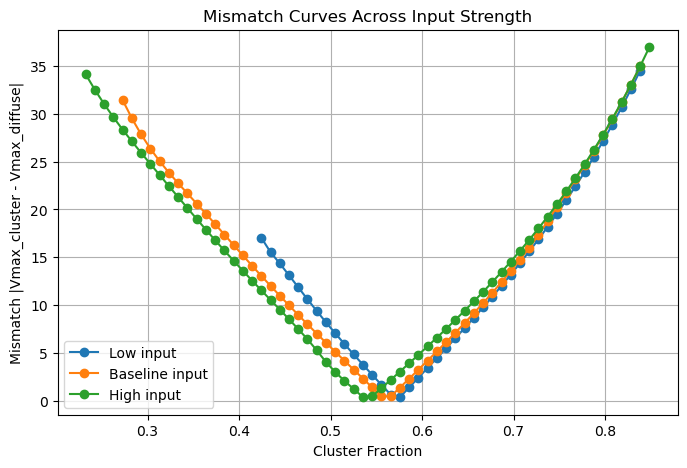

In [57]:
plt.figure(figsize=(8, 5))

for label, results in input_results.items():
    valid_cluster_values = [results["cluster_values"][i] for i in results["both_spike_indices"]]
    plt.plot(valid_cluster_values, results["mismatch_values"], marker='o', label=label)

plt.xlabel("Cluster Fraction")
plt.ylabel("Mismatch |Vmax_cluster - Vmax_diffuse|")
plt.title("Mismatch Curves Across Input Strength")
plt.legend()
plt.grid(True)
plt.savefig("input_mismatch_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

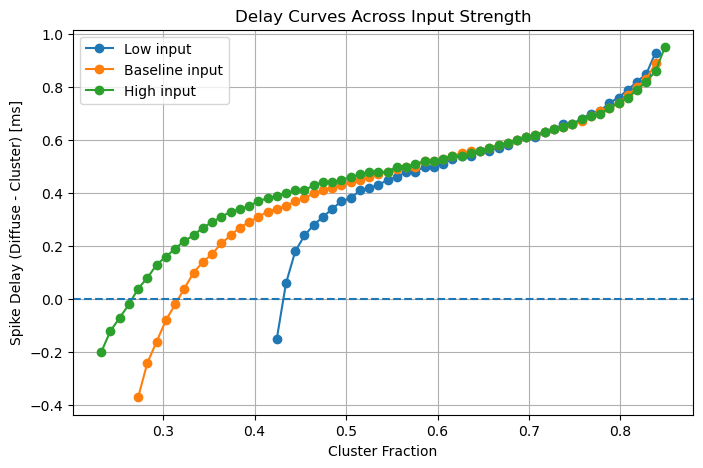

In [58]:
plt.figure(figsize=(8, 5))

for label, results in input_results.items():
    plt.plot(
        results["valid_delay_cluster_values"],
        results["delay_values"],
        marker='o',
        label=label
    )

plt.axhline(0, linestyle='--')
plt.xlabel("Cluster Fraction")
plt.ylabel("Spike Delay (Diffuse - Cluster) [ms]")
plt.title("Delay Curves Across Input Strength")
plt.legend()
plt.grid(True)
plt.savefig("input_delay_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [59]:
phase1_summary = []

for group_name, result_dict in [
    ("Coupling", coupling_results),
    ("Total Sodium", sodium_results),
    ("Input Strength", input_results)
]:
    for label, results in result_dict.items():
        phase1_summary.append({
            "Group": group_name,
            "Condition": label,
            "g_c": results["g_c"],
            "g_Na_total": results["g_Na_total"],
            "I_ext_amp": results["I_ext_amp"],
            "Amplitude optimum": results["optimal_cluster_fraction"],
            "Optimal mismatch": results["optimal_mismatch"],
            "Feasible min": results["feasible_min"],
            "Feasible max": results["feasible_max"]
        })

import pandas as pd
phase1_summary_df = pd.DataFrame(phase1_summary)
phase1_summary_df

,Group,Condition,g_c,g_Na_total,I_ext_amp,Amplitude optimum,Optimal mismatch,Feasible min,Feasible max
0,Coupling,Low coupling,0.5,120.0,20.0,0.525253,0.059579,0.272727,0.282828
1,Coupling,Baseline coupling,1.0,120.0,20.0,0.565657,0.449811,0.272727,0.555556
2,Coupling,High coupling,1.5,120.0,20.0,0.575758,0.067102,0.232323,0.767677
3,Total Sodium,Low total sodium,1.0,100.0,20.0,0.565657,0.431215,0.343434,0.535354
4,Total Sodium,Baseline total sodium,1.0,120.0,20.0,0.565657,0.449811,0.272727,0.555556
5,Total Sodium,High total sodium,1.0,140.0,20.0,0.555556,0.384435,0.212121,0.595960
6,Input Strength,Low input,1.0,120.0,15.0,0.575758,0.371825,0.424242,0.575758
7,Input Strength,Baseline input,1.0,120.0,20.0,0.565657,0.449811,0.272727,0.555556
8,Input Strength,High input,1.0,120.0,25.0,0.535354,0.388236,0.232323,0.545455


In [60]:
regime_labels = []

for c_spike, d_spike in zip(
    baseline_results["cluster_success"],
    baseline_results["diffuse_success"]
):
    if c_spike == 0 and d_spike == 1:
        regime_labels.append("Diffuse only")
    elif c_spike == 1 and d_spike == 1:
        regime_labels.append("Both spike")
    elif c_spike == 1 and d_spike == 0:
        regime_labels.append("Cluster only")
    else:
        regime_labels.append("Neither")

In [61]:
regime_to_y = {
    "Diffuse only": 1,
    "Both spike": 2,
    "Cluster only": 3,
    "Neither": 0
}

regime_y = [regime_to_y[r] for r in regime_labels]

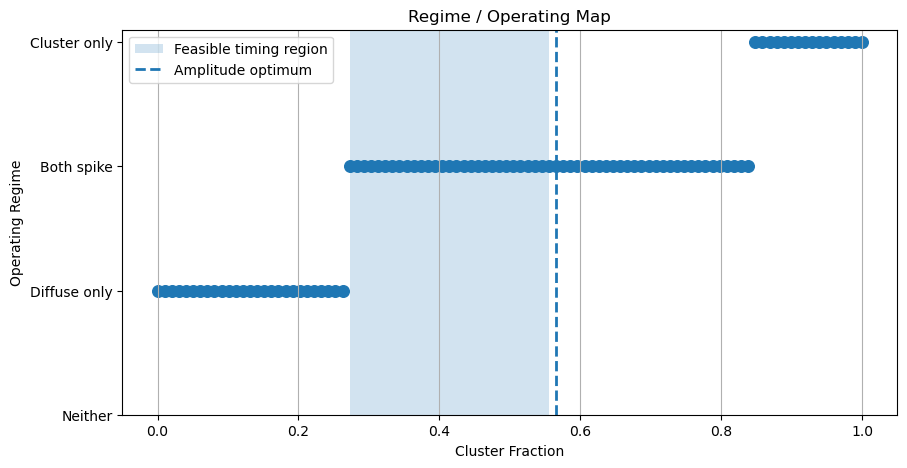

In [62]:
plt.figure(figsize=(10, 5))

# Regime points
plt.scatter(cluster_values, regime_y, s=70)

# Shade feasible timing region
if baseline_results["feasible_min"] is not None and baseline_results["feasible_max"] is not None:
    plt.axvspan(
        baseline_results["feasible_min"],
        baseline_results["feasible_max"],
        alpha=0.2,
        label="Feasible timing region"
    )

# Mark amplitude optimum
plt.axvline(
    baseline_results["optimal_cluster_fraction"],
    linestyle='--',
    linewidth=2,
    label="Amplitude optimum"
)

plt.yticks(
    [0, 1, 2, 3],
    ["Neither", "Diffuse only", "Both spike", "Cluster only"]
)

plt.xlabel("Cluster Fraction")
plt.ylabel("Operating Regime")
plt.title("Regime / Operating Map")
plt.grid(True, axis='x')
plt.legend()
plt.savefig("baseline_regime_operating_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [63]:
def compute_optimum_feasible_gap(results):
    opt = results["optimal_cluster_fraction"]
    feasible_max = results["feasible_max"]

    if opt is None or feasible_max is None:
        return None

    return opt - feasible_max

In [64]:
gap_summary = []

for group_name, result_dict in [
    ("Coupling", coupling_results),
    ("Total Sodium", sodium_results),
    ("Input Strength", input_results)
]:
    for label, results in result_dict.items():
        gap = compute_optimum_feasible_gap(results)

        gap_summary.append({
            "Group": group_name,
            "Condition": label,
            "g_c": results["g_c"],
            "g_Na_total": results["g_Na_total"],
            "I_ext_amp": results["I_ext_amp"],
            "Amplitude optimum": results["optimal_cluster_fraction"],
            "Feasible max": results["feasible_max"],
            "Gap (optimum - feasible max)": gap
        })

gap_summary_df = pd.DataFrame(gap_summary)
gap_summary_df

,Group,Condition,g_c,g_Na_total,I_ext_amp,Amplitude optimum,Feasible max,Gap (optimum - feasible max)
0,Coupling,Low coupling,0.5,120.0,20.0,0.525253,0.282828,0.242424
1,Coupling,Baseline coupling,1.0,120.0,20.0,0.565657,0.555556,0.010101
2,Coupling,High coupling,1.5,120.0,20.0,0.575758,0.767677,-0.191919
3,Total Sodium,Low total sodium,1.0,100.0,20.0,0.565657,0.535354,0.030303
4,Total Sodium,Baseline total sodium,1.0,120.0,20.0,0.565657,0.555556,0.010101
5,Total Sodium,High total sodium,1.0,140.0,20.0,0.555556,0.595960,-0.040404
6,Input Strength,Low input,1.0,120.0,15.0,0.575758,0.575758,0.000000
7,Input Strength,Baseline input,1.0,120.0,20.0,0.565657,0.555556,0.010101
8,Input Strength,High input,1.0,120.0,25.0,0.535354,0.545455,-0.010101


In [65]:
gap_summary_df.sort_values(["Group", "Gap (optimum - feasible max)"])

,Group,Condition,g_c,g_Na_total,I_ext_amp,Amplitude optimum,Feasible max,Gap (optimum - feasible max)
2,Coupling,High coupling,1.5,120.0,20.0,0.575758,0.767677,-0.191919
1,Coupling,Baseline coupling,1.0,120.0,20.0,0.565657,0.555556,0.010101
0,Coupling,Low coupling,0.5,120.0,20.0,0.525253,0.282828,0.242424
8,Input Strength,High input,1.0,120.0,25.0,0.535354,0.545455,-0.010101
6,Input Strength,Low input,1.0,120.0,15.0,0.575758,0.575758,0.000000
7,Input Strength,Baseline input,1.0,120.0,20.0,0.565657,0.555556,0.010101
5,Total Sodium,High total sodium,1.0,140.0,20.0,0.555556,0.595960,-0.040404
4,Total Sodium,Baseline total sodium,1.0,120.0,20.0,0.565657,0.555556,0.010101
3,Total Sodium,Low total sodium,1.0,100.0,20.0,0.565657,0.535354,0.030303


In [66]:
interaction_conditions = {
    "Low coupling + Low input": {"g_c": 0.5, "I_ext_amp": 15.0},
    "Low coupling + High input": {"g_c": 0.5, "I_ext_amp": 25.0},
    "High coupling + Low input": {"g_c": 1.5, "I_ext_amp": 15.0},
    "High coupling + High input": {"g_c": 1.5, "I_ext_amp": 25.0}
}

interaction_results = {}

for label, params in interaction_conditions.items():
    results = analyze_parameter_setting(
        cluster_values=cluster_values,
        g_c=params["g_c"],
        g_Na_total=120.0,
        I_ext_amp=params["I_ext_amp"],
        delay_threshold=delay_threshold
    )
    interaction_results[label] = results
    print_summary(results, label=label)

--- Low coupling + Low input ---
g_c = 0.5
g_Na_total = 120.0
I_ext_amp = 15.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5454545454545455
Cluster max voltage at optimum: 27.0832620439688
Diffuse max voltage at optimum: 26.586644276949478
Voltage mismatch at optimum: 0.49661776701932325

Feasible cluster_fraction range:
0.3535353535353536 to 0.3535353535353536

--- Low coupling + High input ---
g_c = 0.5
g_Na_total = 120.0
I_ext_amp = 25.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5050505050505051
Cluster max voltage at optimum: 29.255229932677523
Diffuse max voltage at optimum: 29.316833201887302
Voltage mismatch at optimum: 0.061603269209779654

Feasible cluster_fraction range:
0.24242424242424243 to 0.25252525252525254

--- High coupling + Low input ---
g_c = 1.5
g_Na_total = 120.0
I_ext_amp = 15.0
delay_threshold = 0.5

Amplitude optimum cluster_fraction: 0.5858585858585859
Cluster max voltage at optimum: 24.0695916832918
Diffuse max voltage at 

In [67]:
interaction_summary = []

for label, results in interaction_results.items():
    gap = compute_optimum_feasible_gap(results)

    interaction_summary.append({
        "Condition": label,
        "g_c": results["g_c"],
        "I_ext_amp": results["I_ext_amp"],
        "Amplitude optimum": results["optimal_cluster_fraction"],
        "Feasible min": results["feasible_min"],
        "Feasible max": results["feasible_max"],
        "Gap (optimum - feasible max)": gap
    })

interaction_summary_df = pd.DataFrame(interaction_summary)
interaction_summary_df

,Condition,g_c,I_ext_amp,Amplitude optimum,Feasible min,Feasible max,Gap (optimum - feasible max)
0,Low coupling + Low input,0.5,15.0,0.545455,0.353535,0.353535,0.191919
1,Low coupling + High input,0.5,25.0,0.505051,0.242424,0.252525,0.252525
2,High coupling + Low input,1.5,15.0,0.585859,0.474747,0.767677,-0.181818
3,High coupling + High input,1.5,25.0,0.565657,0.202020,0.767677,-0.202020


In [68]:
interaction_summary_df.sort_values("Gap (optimum - feasible max)")

,Condition,g_c,I_ext_amp,Amplitude optimum,Feasible min,Feasible max,Gap (optimum - feasible max)
3,High coupling + High input,1.5,25.0,0.565657,0.202020,0.767677,-0.202020
2,High coupling + Low input,1.5,15.0,0.585859,0.474747,0.767677,-0.181818
0,Low coupling + Low input,0.5,15.0,0.545455,0.353535,0.353535,0.191919
1,Low coupling + High input,0.5,25.0,0.505051,0.242424,0.252525,0.252525


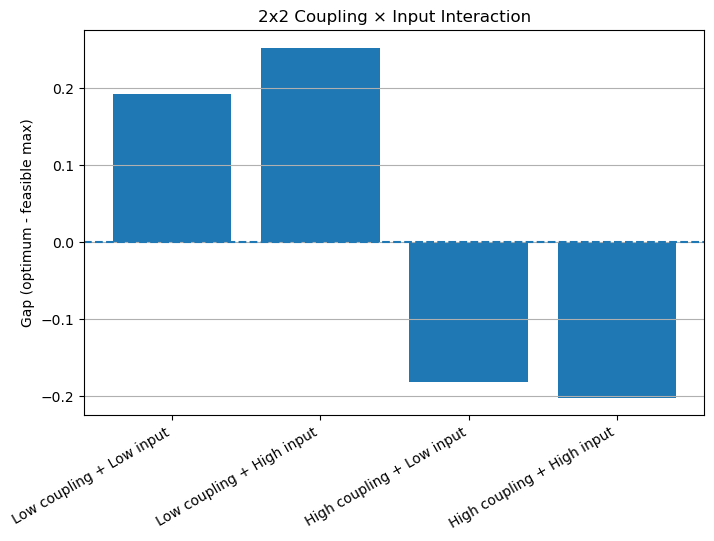

In [69]:
plot_df = interaction_summary_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["Condition"], plot_df["Gap (optimum - feasible max)"])
plt.axhline(0, linestyle='--')
plt.ylabel("Gap (optimum - feasible max)")
plt.title("2x2 Coupling × Input Interaction")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis='y')
plt.savefig("interaction_gap_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

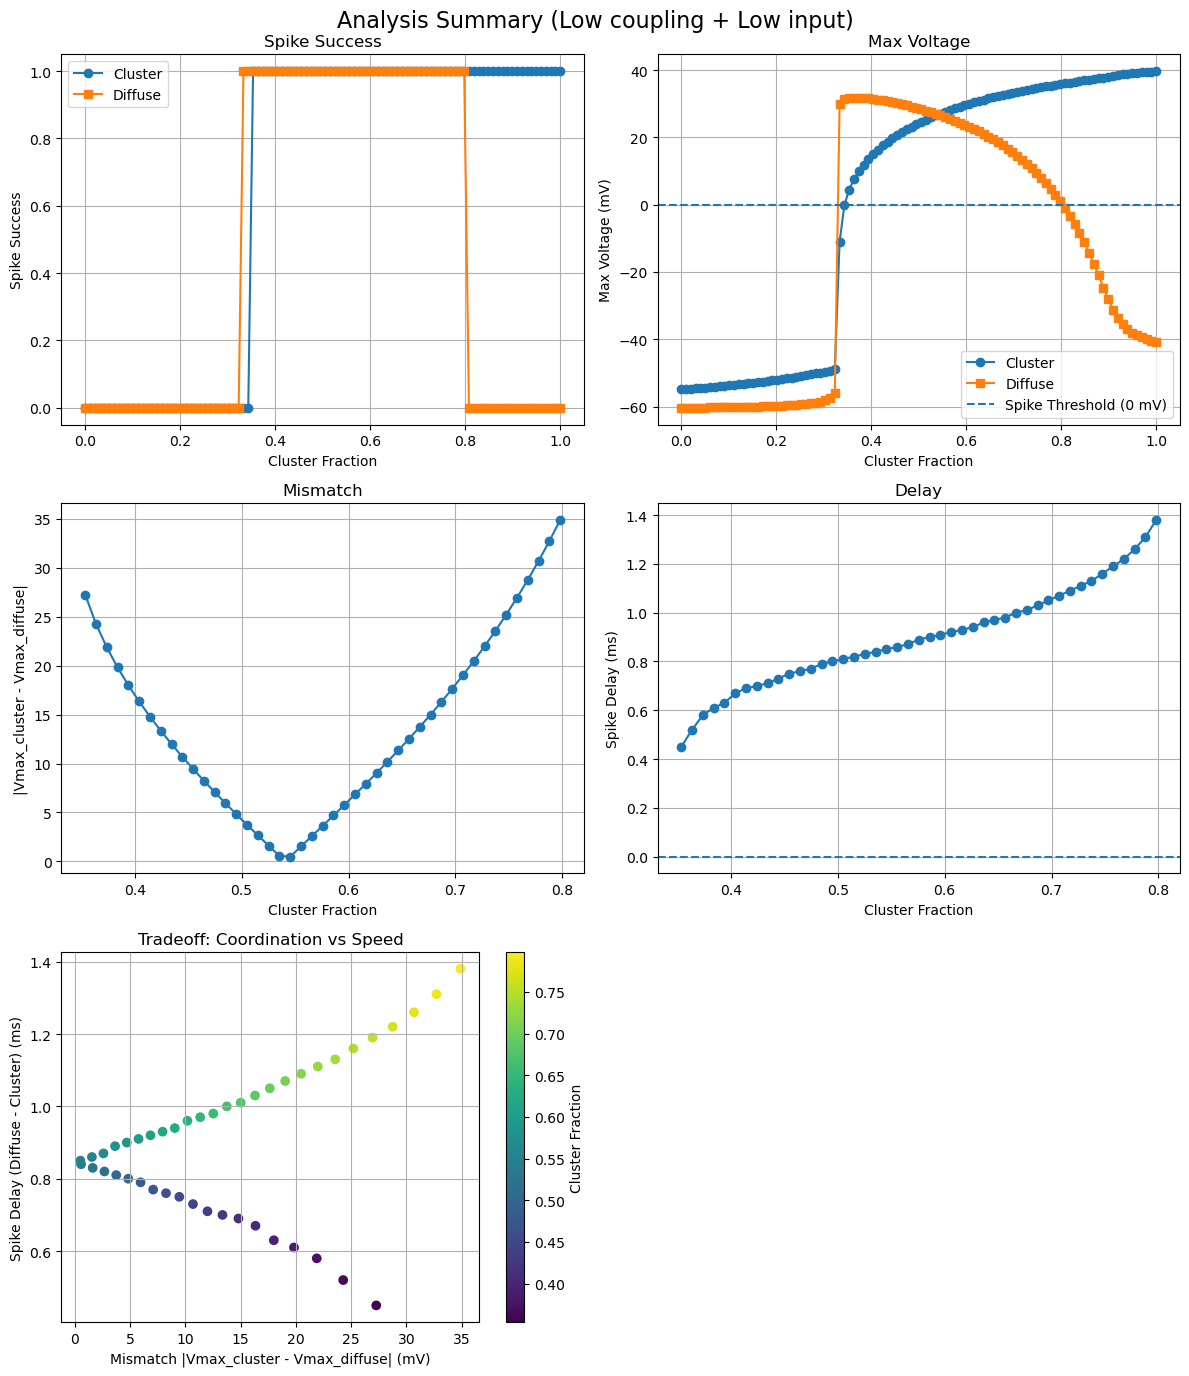

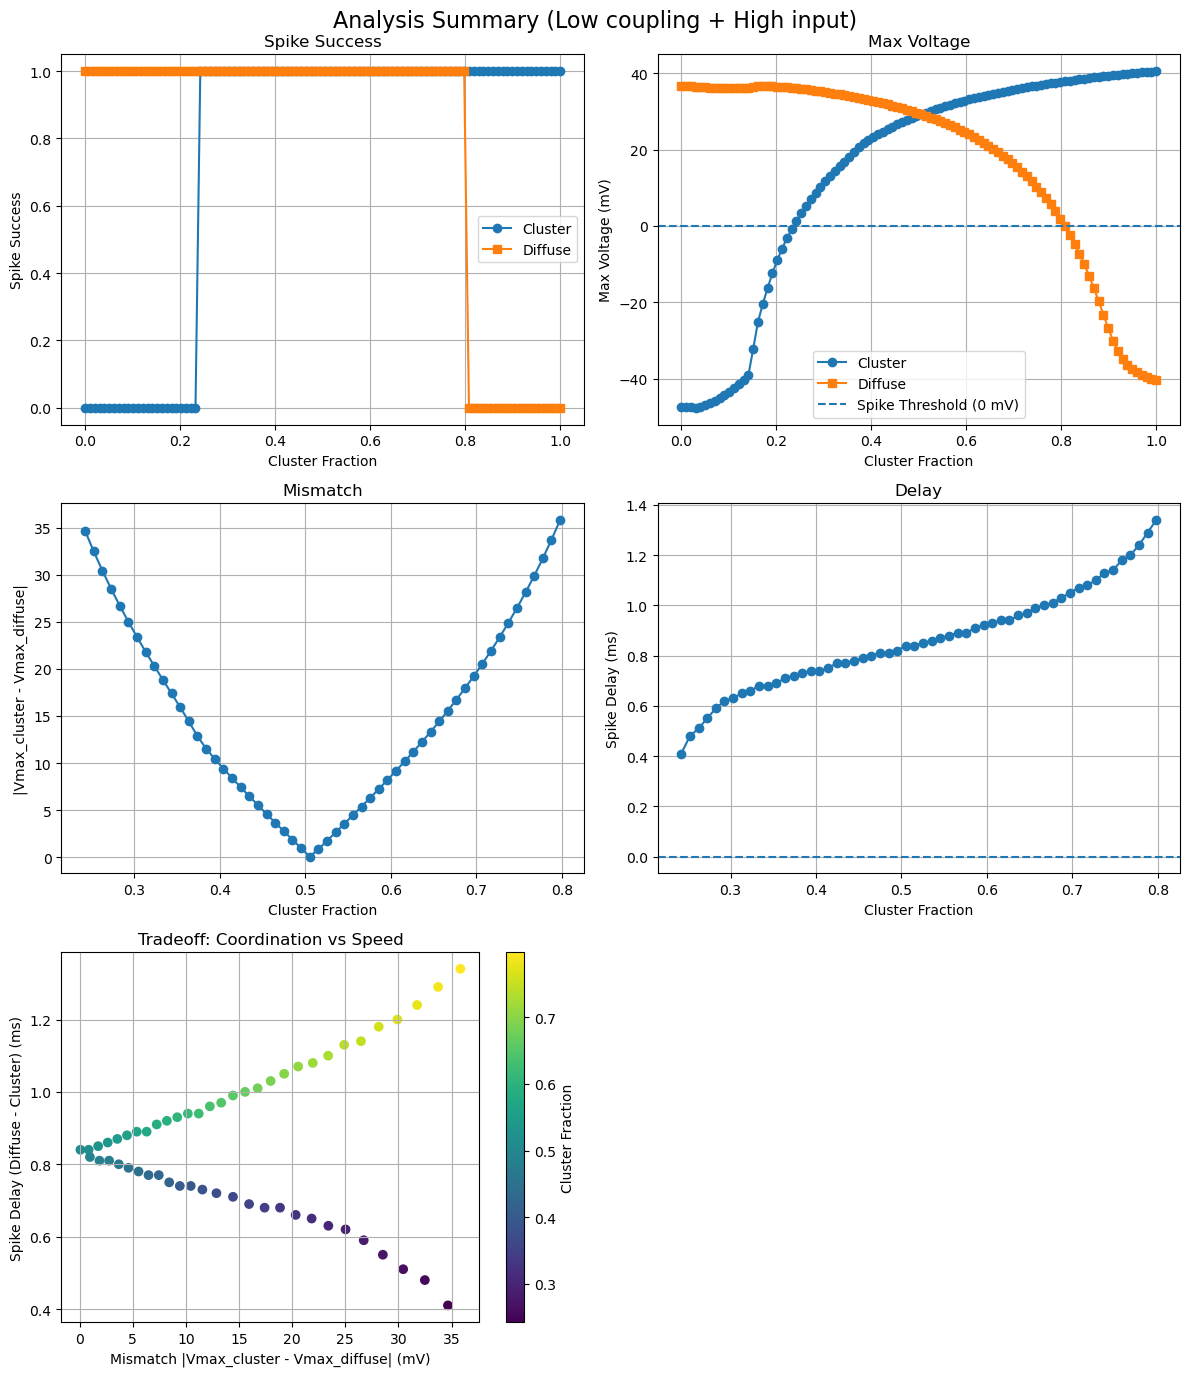

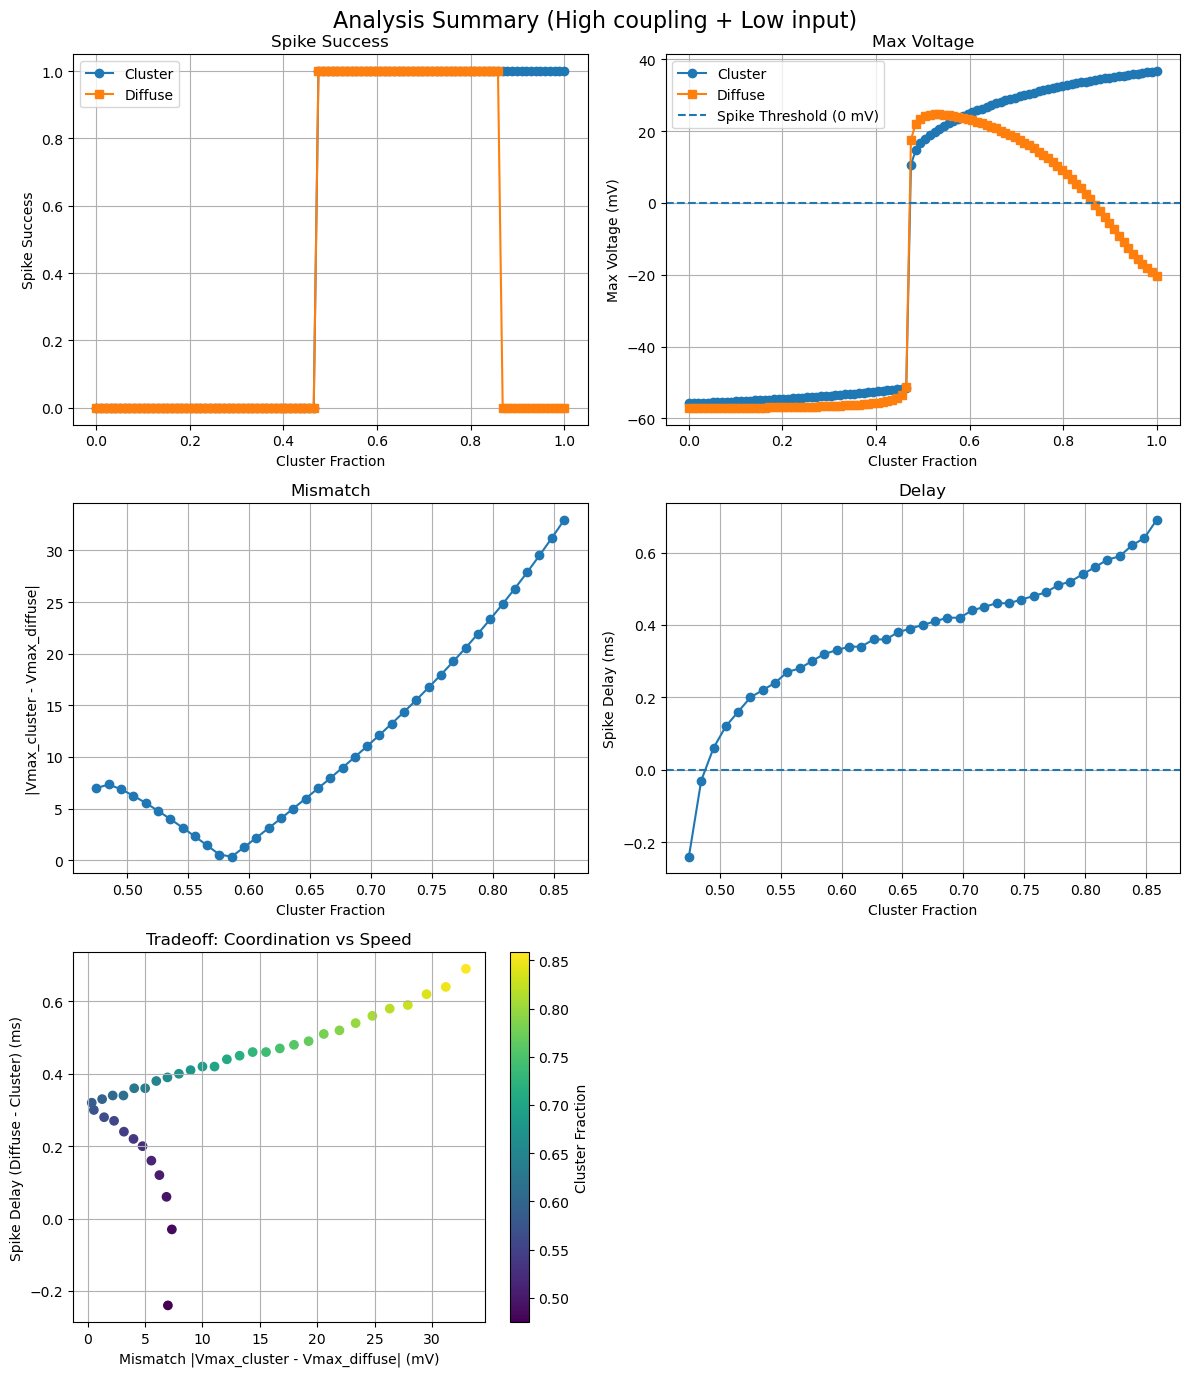

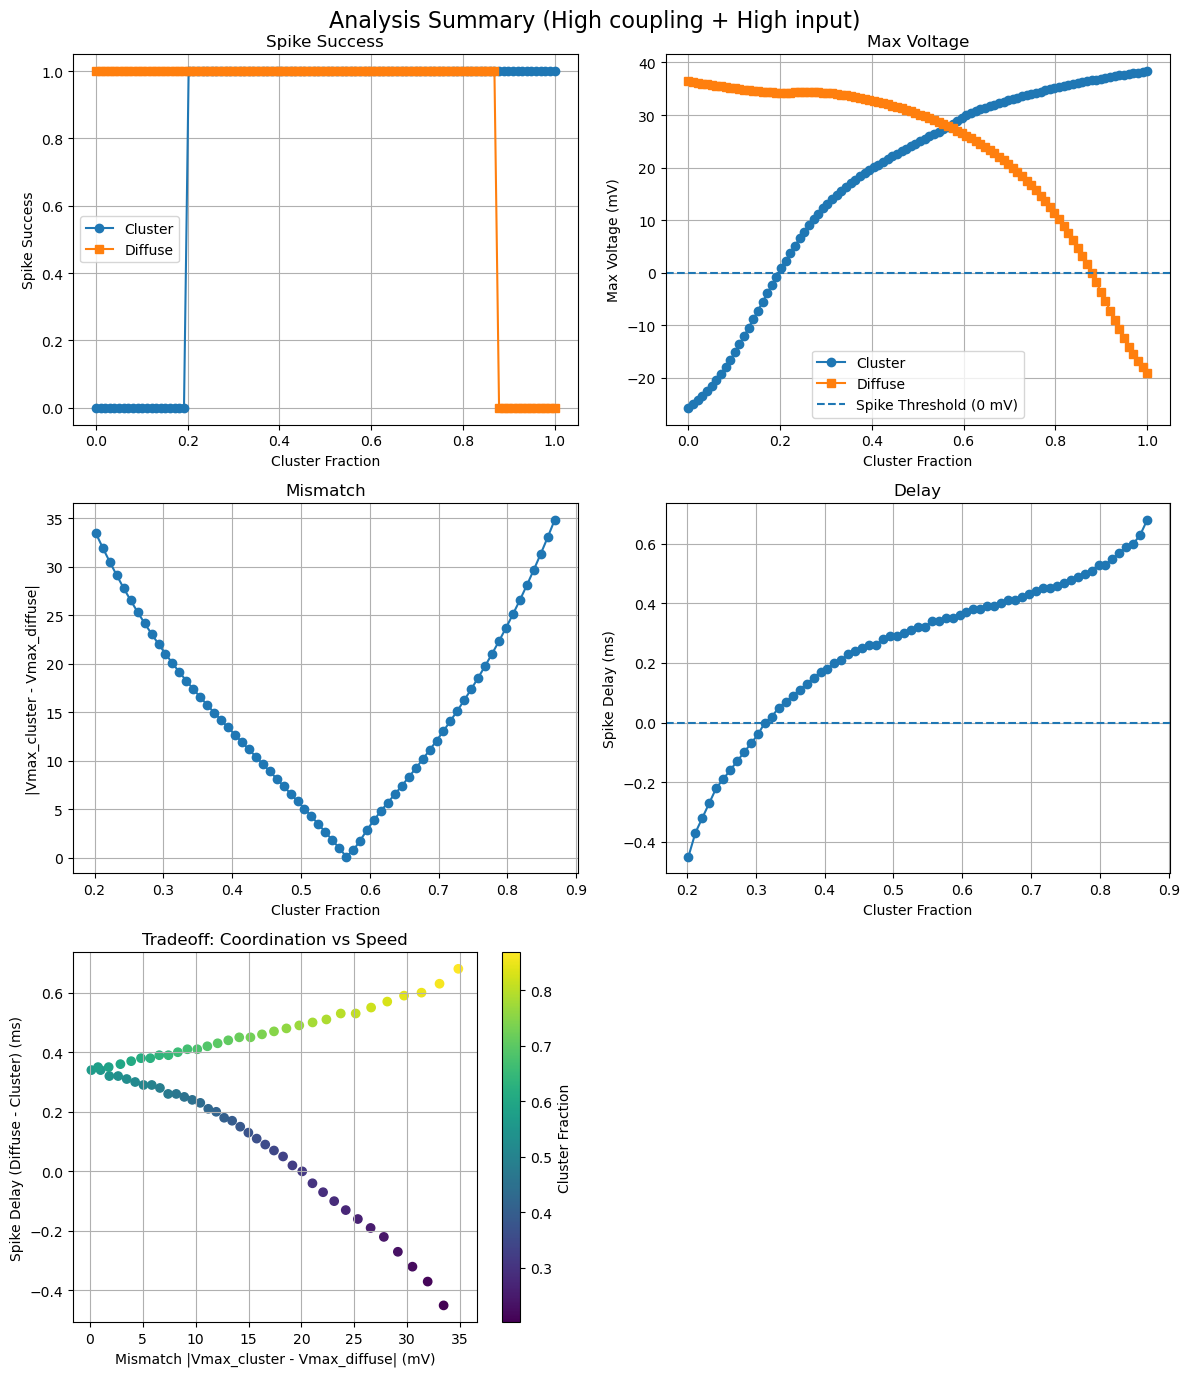

In [70]:
for label, results in interaction_results.items():
    safe_label = label.lower().replace(" ", "_").replace("+", "plus")
    plot_analysis_results_combined(
        results,
        title_suffix=f"({label})",
        save_name=f"{safe_label}_analysis_summary.png"
    )